# Notebook 7 — Comparaison avec le Masked PSNR

**Objectif :** Reprendre les évaluations de reconstruction des Notebooks 5 et 6
(baseline vs cVAE quality-aware, approches A, B et C, ablation $c$ constant) en
remplaçant/complétant le **PSNR classique** (calculé sur l'image entière) par le
**Masked PSNR** défini dans `medvae_eval/scripts/masked_psnr.py`.

### Principe du Masked PSNR

Le PSNR classique traite tous les pixels de la même façon. Sur les images ARCADE
(angiographie coronarienne), l'information cliniquement utile — l'arbre vasculaire —
n'occupe qu'une petite fraction de l'image ; le reste est fond/tissus mous.
Le `MaskedPSNR` utilise les polygones de segmentation (annotations COCO du challenge
ARCADE) pour ne calculer le MSE (et donc le PSNR) **que sur les pixels appartenant
aux vaisseaux** :

$$\text{MaskedPSNR} = 10 \log_{10}\frac{R^2}{\text{MSE}_{\text{pixels} \in \text{masque}}}$$

contre

$$\text{PSNR classique} = 10 \log_{10}\frac{R^2}{\text{MSE}_{\text{tous pixels}}}$$

### Correction importante par rapport à une première version de ce notebook

Une première version conditionnait **tous** les cVAE (approche A et B) avec la colonne
générique `quality_score` du CSV, qui ne reflète que l'approche avec laquelle le
Notebook 3 a été exécuté en dernier. Le `cvae_A` était donc évalué avec le score de
l'approche B (`score_pca`) au lieu du sien (`score_weighted`). **Ce notebook corrige
le problème** : chaque modèle est désormais conditionné avec la colonne de score
de sa propre approche (`score_weighted` pour les modèles `_A`, `score_pca` pour `_B`,
`score_dl` pour `_C`), et les seuils bad/medium/good sont recalculés indépendamment
pour chaque approche (sur TRAIN uniquement), au lieu de réutiliser une unique colonne
`quality_label` figée sur une seule approche.

**Modèles comparés :**

| Modèle | Origine | Score d'entrée |
|---|---|---|
| `baseline_A` / `cvae_A` | NB04 (approche A) | `score_weighted` (poids PCA) |
| `baseline_B` / `cvae_B` | NB04 (approche B) | `score_pca` |
| `baseline_C` / `cvae_C` | NB04 (approche C) | `score_dl` (MLP appris) |
| `cvae_constB` | NB06 (ablation, approche B) | `score_pca`, mais entraîné avec $c=0.5$ constant |

## 0. Configuration

In [1]:
import os, sys, json, warnings, random
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
MEDVAE_EVAL  = PROJECT_ROOT / "medvae_eval"
SCRIPTS_DIR  = MEDVAE_EVAL / "scripts"
sys.path.insert(0, str(SCRIPTS_DIR))

# Dataset : $ARCADE_ROOT si défini, sinon <repo>/data/arcade
ARCADE_ROOT  = Path(os.environ.get("ARCADE_ROOT", PROJECT_ROOT / "data" / "arcade"))
SEG_TRAIN    = ARCADE_ROOT / "dataset_phase_1/segmentation_dataset/seg_train"
SEG_VAL      = ARCADE_ROOT / "dataset_phase_1/segmentation_dataset/seg_val"
TRAIN_ANN    = SEG_TRAIN / "annotations/seg_train.json"
VAL_ANN      = SEG_VAL   / "annotations/seg_val.json"

NB03_DIR  = Path("outputs_theophile/03_Inductive_Bias_Generation")
NB04_DIRS = {k: Path(f"outputs_theophile/04_MedVAE_Architecture_Mod/approach_{k}/checkpoints") for k in ["A", "B", "C"]}
NB06_DIRS = {k: Path(f"outputs_theophile/06_Ablation_c_Constant/approach_{k}/checkpoints") for k in ["A", "B", "C"]}
LABELS_CSV = NB03_DIR / "labels_quality.csv"

OUTPUT_DIR  = Path("outputs_theophile/07_Masked_PSNR_Comparison")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR  = OUTPUT_DIR / "tables"
for _d in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

DDCONFIG = {
    "double_z": True, "z_channels": 4, "resolution": 64,
    "in_channels": 1, "out_ch": 1, "ch": 128,
    "ch_mult": [1, 2, 4], "num_res_blocks": 2,
    "attn_resolutions": [], "dropout": 0.0,
}
EMBED_DIM = 4
IMG_SIZE  = DDCONFIG["resolution"]

N_TEST_PER_CLASS = 20
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

print(f"TRAIN_ANN exists: {TRAIN_ANN.exists()}")
print(f"VAL_ANN exists:   {VAL_ANN.exists()}")
print(f"Sorties: {OUTPUT_DIR}")

TRAIN_ANN exists: True
VAL_ANN exists:   True
Sorties: outputs_theophile/07_Masked_PSNR_Comparison


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from scipy import stats

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

from medvae_standalone import AutoencoderKL as AutoencoderKL2D
from medvae_standalone import DiagonalGaussianDistribution
from masked_psnr import MaskedPSNR

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


## 2. Architecture cVAE (FiLM)

*(Redéfinie ici à l'identique des Notebooks 4/5/6 pour rendre ce notebook autonome.)*

In [3]:
class FiLMConditioner(nn.Module):
    def __init__(self, channels_per_block: list, hidden_dim: int = 128):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
        )
        self.heads = nn.ModuleList()
        for ch in channels_per_block:
            head = nn.Linear(hidden_dim, 2 * ch)
            nn.init.zeros_(head.weight)
            nn.init.zeros_(head.bias)
            self.heads.append(head)

    def forward(self, c):
        emb = self.embed(c.view(-1, 1))
        return [
            (gb[:, :gb.shape[1]//2].unsqueeze(-1).unsqueeze(-1),
             gb[:, gb.shape[1]//2:].unsqueeze(-1).unsqueeze(-1))
            for gb in (head(emb) for head in self.heads)
        ]


class QualityAwareAutoencoderKL(nn.Module):
    def __init__(self, base_ae: AutoencoderKL2D):
        super().__init__()
        self.ae = base_ae
        self._blocks = list(self._iter_resnet_blocks())
        channels = [b.conv2.out_channels for b in self._blocks]
        self.film = FiLMConditioner(channels)

    def _iter_resnet_blocks(self):
        enc = self.ae.encoder
        for i_level in range(enc.num_resolutions):
            for i_block in range(enc.num_res_blocks):
                yield enc.down[i_level].block[i_block]
        yield enc.mid.block_1
        yield enc.mid.block_2
        dec = self.ae.decoder
        yield dec.mid.block_1
        yield dec.mid.block_2
        for i_level in reversed(range(dec.num_resolutions)):
            for i_block in range(dec.num_res_blocks + 1):
                yield dec.up[i_level].block[i_block]

    def _register_film_hooks(self, c):
        film_params = self.film(c)
        hooks = []
        for i, block in enumerate(self._blocks):
            gamma, beta = film_params[i]
            hook = block.register_forward_hook(
                lambda mod, inp, out, g=gamma, b=beta: (1 + g) * out + b
            )
            hooks.append(hook)
        return hooks

    def forward(self, x, c, sample_posterior=True):
        hooks = self._register_film_hooks(c)
        try:
            h = self.ae.encoder(x)
            moments = self.ae.quant_conv(h)
            posterior = DiagonalGaussianDistribution(moments)
            z = posterior.sample() if sample_posterior else posterior.mode()
            dec = self.ae.decoder(self.ae.post_quant_conv(z))
        finally:
            for hk in hooks:
                hk.remove()
        return dec, posterior

    def get_last_layer(self):
        return self.ae.get_last_layer()


print("QualityAwareAutoencoderKL définie (FiLM).")

QualityAwareAutoencoderKL définie (FiLM).


## 3. Masked PSNR — mise en place et visualisation des masques

On instancie un `MaskedPSNR` par split (train / val), car les annotations COCO
ARCADE sont séparées par split. Le `data_range` est fixé à 255 pour être directement
comparable au PSNR classique calculé par `skimage` sur des images `uint8`.

In [4]:
masked_psnr_train = MaskedPSNR(str(TRAIN_ANN), data_range=255.0).to(DEVICE)
masked_psnr_val   = MaskedPSNR(str(VAL_ANN),   data_range=255.0).to(DEVICE)

def get_masked_psnr_module(split: str) -> MaskedPSNR:
    return masked_psnr_train if split == "train" else masked_psnr_val


def masked_mask_for(path: str, split: str, size: int = IMG_SIZE) -> np.ndarray:
    """Renvoie le masque binaire (size, size) déjà redimensionné, pour visualisation."""
    mp = get_masked_psnr_module(split)
    fname = Path(path).name
    m = mp._mask(fname)
    return cv2.resize(m, (size, size), interpolation=cv2.INTER_NEAREST)


print("MaskedPSNR (train/val) instanciés.")

MaskedPSNR (train/val) instanciés.


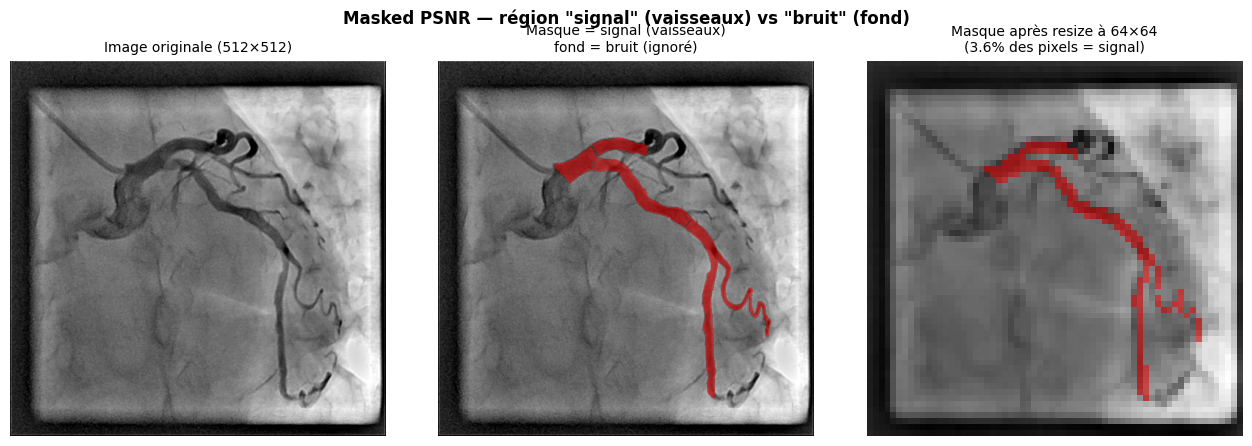

In [5]:
# Visualisation : exemple de masque (signal = vaisseaux) à 512 et à 64
df_labels_preview = pd.read_csv(LABELS_CSV)
example_row = df_labels_preview[df_labels_preview["split"] == "train"].iloc[3]
example_path = example_row["path"]

mask_512 = masked_psnr_train._mask(Path(example_path).name)
mask_64  = masked_mask_for(example_path, "train", size=IMG_SIZE)
img_512  = np.asarray(Image.open(example_path).convert("L"))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(img_512, cmap="gray")
axes[0].set_title("Image originale (512×512)", fontsize=10)
axes[0].axis("off")

axes[1].imshow(img_512, cmap="gray")
axes[1].imshow(np.ma.masked_where(mask_512 == 0, mask_512), cmap="autumn", alpha=0.5)
axes[1].set_title("Masque = signal (vaisseaux)\nfond = bruit (ignoré)", fontsize=10)
axes[1].axis("off")

img_64 = np.asarray(Image.open(example_path).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR))
axes[2].imshow(img_64, cmap="gray")
axes[2].imshow(np.ma.masked_where(mask_64 == 0, mask_64), cmap="autumn", alpha=0.5)
frac = mask_64.mean() * 100
axes[2].set_title(f"Masque après resize à {IMG_SIZE}×{IMG_SIZE}\n({frac:.1f}% des pixels = signal)", fontsize=10)
axes[2].axis("off")

fig.suptitle("Masked PSNR — région \"signal\" (vaisseaux) vs \"bruit\" (fond)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_mask_explanation.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# Statistique de couverture du masque à 64x64 sur un échantillon — vérifie qu'on
# n'a pas de masques vides après le downsampling agressif (512 -> 64).
sample_check = df_labels_preview.sample(min(200, len(df_labels_preview)), random_state=RANDOM_SEED)
coverages = []
for _, row in sample_check.iterrows():
    m64 = masked_mask_for(row["path"], row["split"], size=IMG_SIZE)
    coverages.append(m64.sum())
coverages = np.array(coverages)

print(f"Couverture masque @ {IMG_SIZE}x{IMG_SIZE} (n={len(coverages)})")
print(f"  moyenne : {coverages.mean():.1f} px ({coverages.mean()/IMG_SIZE**2*100:.2f}% de l'image)")
print(f"  min     : {coverages.min()} px")
print(f"  images à masque vide : {(coverages == 0).sum()} / {len(coverages)}")

Couverture masque @ 64x64 (n=200)
  moyenne : 135.9 px (3.32% de l'image)
  min     : 20 px
  images à masque vide : 0 / 200


## 4. Chargement des modèles (NB04 approches A/B/C + NB06 ablation)

In [7]:
def load_cvae(ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    base_ae = AutoencoderKL2D(ddconfig=ckpt["ddconfig"], embed_dim=ckpt["embed_dim"],
                               apply_channel_ds=True)
    model = QualityAwareAutoencoderKL(base_ae)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(DEVICE).eval(), ckpt


def load_baseline_from_ckpt(ckpt_data: dict):
    baseline = AutoencoderKL2D(ddconfig=DDCONFIG, embed_dim=EMBED_DIM, apply_channel_ds=True).to(DEVICE)
    if "baseline_state_dict" in ckpt_data:
        baseline.load_state_dict(ckpt_data["baseline_state_dict"])
    return baseline.eval()


models = {}
# score_col associé à chaque famille de modèle (cf. pipeline_config.py)
MODEL_SCORE_COL = {}
SCORE_COL_BY_APPROACH = {"A": "score_weighted", "B": "score_pca", "C": "score_dl"}

for approach_key, score_col in SCORE_COL_BY_APPROACH.items():
    ckpt_path = NB04_DIRS[approach_key] / "quality_aware_vae.pt"
    if not ckpt_path.exists():
        print(f"[!] Checkpoint introuvable pour l'approche {approach_key} : {ckpt_path} — ignorée.")
        continue
    cvae, ckpt = load_cvae(ckpt_path)
    baseline = load_baseline_from_ckpt(ckpt)
    models[f"baseline_{approach_key}"] = baseline
    models[f"cvae_{approach_key}"] = cvae
    MODEL_SCORE_COL[f"baseline_{approach_key}"] = score_col
    MODEL_SCORE_COL[f"cvae_{approach_key}"] = score_col

# Ablation c constant — une par approche disponible (NB06 relancé pour A, B et/ou C)
C_CONSTANT = {}
for approach_key, score_col in SCORE_COL_BY_APPROACH.items():
    ckpt_path = NB06_DIRS[approach_key] / "quality_aware_vae_c_constant.pt"
    if not ckpt_path.exists():
        print(f"[!] Checkpoint NB06 (c constant) introuvable pour l'approche {approach_key} : {ckpt_path} — ablation ignorée.")
        continue
    cvae_const, ckpt_const = load_cvae(ckpt_path)
    models[f"cvae_const{approach_key}"] = cvae_const
    MODEL_SCORE_COL[f"cvae_const{approach_key}"] = score_col
    C_CONSTANT[approach_key] = ckpt_const.get("c_constant", 0.5)

for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:14s} : {n_params:,} paramètres  (score = {MODEL_SCORE_COL[name]})")

baseline_A     : 55,358,845 paramètres  (score = score_weighted)
cvae_A         : 57,059,837 paramètres  (score = score_weighted)
baseline_B     : 55,358,845 paramètres  (score = score_pca)
cvae_B         : 57,059,837 paramètres  (score = score_pca)
baseline_C     : 55,358,845 paramètres  (score = score_dl)
cvae_C         : 57,059,837 paramètres  (score = score_dl)
cvae_constA    : 57,059,837 paramètres  (score = score_weighted)
cvae_constB    : 57,059,837 paramètres  (score = score_pca)
cvae_constC    : 57,059,837 paramètres  (score = score_dl)


## 5. Jeux de test — un par approche (tertiles recalculés sur TRAIN uniquement)

**Correction du bug :** au lieu de réutiliser une colonne `quality_label` unique
(figée sur l'approche avec laquelle le Notebook 3 a été exécuté en dernier), on
recalcule les tertiles bad/medium/good **indépendamment pour chaque approche**, à
partir de sa propre colonne de score (`score_weighted`, `score_pca`, `score_dl`),
en suivant exactement la même règle que le Notebook 3 section 12 (seuils calculés
sur TRAIN uniquement).

In [8]:
df_labels = pd.read_csv(LABELS_CSV)
print(f"Dataset : {len(df_labels)} images")
print(f"Colonnes de score disponibles : {[c for c in df_labels.columns if c.startswith('score_')]}")


def build_test_sets(df: pd.DataFrame, score_col: str, n_per_class: int = N_TEST_PER_CLASS,
                     seed: int = RANDOM_SEED) -> dict:
    """Recalcule les tertiles bad/medium/good sur TRAIN pour `score_col`, puis
    échantillonne n_per_class images par classe (mêmes règles que NB03 section 12)."""
    valid = df[df[score_col].notna() & df["path"].apply(lambda p: Path(p).exists())].copy()
    train_scores = valid.loc[valid["split"] == "train", score_col]
    t33, t67 = train_scores.quantile(1 / 3), train_scores.quantile(2 / 3)

    def assign_label(s):
        if s < t33:
            return "bad"
        elif s < t67:
            return "medium"
        return "good"

    valid["_label"] = valid[score_col].apply(assign_label)

    out = {}
    for label in ["bad", "medium", "good"]:
        subset = valid[valid["_label"] == label]
        sampled = subset.sample(min(n_per_class, len(subset)), random_state=seed)
        out[label] = sampled.reset_index(drop=True)
    return out


test_sets_by_approach = {}
for key, score_col in [("A", "score_weighted"), ("B", "score_pca"), ("C", "score_dl")]:
    if f"cvae_{key}" not in models:
        continue
    ts = build_test_sets(df_labels, score_col)
    test_sets_by_approach[key] = ts
    print(f"Approche {key} ({score_col}) : " + ", ".join(f"{l}={len(ts[l])}" for l in ts))

Dataset : 1200 images
Colonnes de score disponibles : ['score_weighted', 'score_pca', 'score_dl']
Approche A (score_weighted) : bad=20, medium=20, good=20
Approche B (score_pca) : bad=20, medium=20, good=20
Approche C (score_dl) : bad=20, medium=20, good=20


## 6. Fonctions utilitaires : chargement et métriques (classique + masked)

In [9]:
def load_tensor(path: str, size: int = IMG_SIZE) -> torch.Tensor:
    img = Image.open(path).convert("L").resize((size, size), Image.Resampling.BILINEAR)
    t = torch.from_numpy(np.asarray(img, np.float32) / 255.0)
    return (t.unsqueeze(0).unsqueeze(0) * 2.0 - 1.0)


def to_uint8(t: torch.Tensor) -> np.ndarray:
    arr = t.squeeze().cpu().numpy()
    return ((arr.clip(-1, 1) + 1) / 2 * 255).astype(np.uint8)


def to_255_tensor(t: torch.Tensor) -> torch.Tensor:
    """[-1,1] (1,1,H,W) -> [0,255] float tensor, même device, pour MaskedPSNR."""
    return (t.clamp(-1, 1) + 1) / 2 * 255.0


def compute_all_metrics(original: torch.Tensor, reconstruction: torch.Tensor,
                         path: str, split: str) -> dict:
    """original, reconstruction : (1,1,H,W) dans [-1,1]. Retourne classique + masked PSNR."""
    mse = float(F.mse_loss(reconstruction, original).item())

    orig_u8 = to_uint8(original)
    rec_u8 = to_uint8(reconstruction)
    ssim_val = float(ssim_fn(orig_u8, rec_u8, data_range=255))
    psnr_val = float(psnr_fn(orig_u8, rec_u8, data_range=255))

    mp = get_masked_psnr_module(split)
    mp.set_image(Path(path).name)
    orig_255 = to_255_tensor(original)
    rec_255 = to_255_tensor(reconstruction)
    mpsnr_t = mp(rec_255, orig_255)
    mpsnr_val = float(mpsnr_t.item()) if torch.isfinite(mpsnr_t) else float("inf")

    return {"mse": mse, "ssim": ssim_val, "psnr": psnr_val, "masked_psnr": mpsnr_val}


print("compute_all_metrics défini (MSE, SSIM, PSNR classique, Masked PSNR).")

compute_all_metrics défini (MSE, SSIM, PSNR classique, Masked PSNR).


## 7. Évaluation quantitative — images réelles

Pour chaque approche, le cVAE est conditionné avec **sa propre colonne de score**
(`MODEL_SCORE_COL`), évalué sur son propre jeu de test stratifié (`test_sets_by_approach`).
Pour chaque approche où l'ablation NB06 est disponible, `cvae_const{X}` est évaluée sur le
jeu de test de cette même approche X (même score d'entrée), comparée à `cvae_X`.

In [10]:
def _forward_model(model, x, c):
    """Gère les deux signatures : AutoencoderKL2D (pas de c) vs QualityAwareAutoencoderKL (FiLM)."""
    if isinstance(model, QualityAwareAutoencoderKL):
        rec, _ = model(x, c, sample_posterior=False)
    else:
        rec, _, _ = model(x, sample_posterior=False, decode=True)
    return rec


@torch.no_grad()
def evaluate_pair(test_sets: dict, score_col: str, baseline_model, cvae_model,
                   base_name: str, cvae_name: str) -> pd.DataFrame:
    records = []
    for label, df_subset in test_sets.items():
        for _, row in tqdm(df_subset.iterrows(), total=len(df_subset), desc=f"{base_name[:4]}/{cvae_name[:4]} {label:6s}", leave=False):
            path, split = row["path"], row["split"]
            try:
                x = load_tensor(path).to(DEVICE)
            except Exception:
                continue
            c = torch.tensor([row[score_col]], dtype=torch.float32, device=DEVICE)

            rec_base = _forward_model(baseline_model, x, c)
            rec_cvae = _forward_model(cvae_model, x, c)

            m_base = compute_all_metrics(x, rec_base, path, split)
            m_cvae = compute_all_metrics(x, rec_cvae, path, split)

            records.append({
                "image_id": row["image_id"], "path": path, "split": split,
                "quality_label": label, "quality_score": row[score_col],
                **{f"base_{k}": v for k, v in m_base.items()},
                **{f"cvae_{k}": v for k, v in m_cvae.items()},
            })
    return pd.DataFrame(records)


comparisons = []  # liste de dicts : {"name", "base_name", "cvae_name", "df"}
for key in ["A", "B", "C"]:
    if key not in test_sets_by_approach:
        continue
    score_col = MODEL_SCORE_COL[f"cvae_{key}"]
    df_cmp = evaluate_pair(test_sets_by_approach[key], score_col,
                            models[f"baseline_{key}"], models[f"cvae_{key}"],
                            f"baseline_{key}", f"cvae_{key}")
    comparisons.append({"name": f"baseline_{key} vs cvae_{key}", "base_name": f"baseline_{key}",
                         "cvae_name": f"cvae_{key}", "approach": key, "df": df_cmp})
    print(f"Approche {key} : {len(df_cmp)} images évaluées")

# Ablation c constant — une comparaison par approche où NB06 a été relancé
for key in ["A", "B", "C"]:
    const_name = f"cvae_const{key}"
    if const_name not in models or key not in test_sets_by_approach:
        continue
    score_col = MODEL_SCORE_COL[const_name]
    df_ablation = evaluate_pair(test_sets_by_approach[key], score_col,
                                 models[f"cvae_{key}"], models[const_name],
                                 f"cvae_{key}", const_name)
    comparisons.append({"name": f"cvae_{key} vs {const_name}", "base_name": f"cvae_{key}",
                         "cvae_name": const_name, "approach": f"ablation_{key}", "df": df_ablation})
    print(f"Ablation {key} : {len(df_ablation)} images évaluées")

Approche A : 60 images évaluées


Approche B : 60 images évaluées


Approche C : 60 images évaluées


Ablation A : 60 images évaluées


Ablation B : 60 images évaluées


Ablation C : 60 images évaluées


## 8. Tableau comparatif — PSNR classique vs Masked PSNR

In [11]:
label_order = ["bad", "medium", "good"]
rows = []
for cmp in comparisons:
    df_cmp = cmp["df"]
    for label in label_order:
        sub = df_cmp[df_cmp["quality_label"] == label]
        for role, name in [("base", cmp["base_name"]), ("cvae", cmp["cvae_name"])]:
            rows.append({
                "comparaison": cmp["name"],
                "quality_label": label,
                "model": name,
                "psnr_classique": sub[f"{role}_psnr"].mean(),
                "masked_psnr": sub[f"{role}_masked_psnr"].mean(),
                "delta (masked - classique)": sub[f"{role}_masked_psnr"].mean() - sub[f"{role}_psnr"].mean(),
            })
df_psnr_table = pd.DataFrame(rows).round(3)
df_psnr_table.to_csv(TABLES_DIR / "07_psnr_comparison_table.csv", index=False)
df_psnr_table

,comparaison,quality_label,model,psnr_classique,masked_psnr,delta (masked - classique)
0,baseline_A vs cvae_A,bad,baseline_A,33.870,31.417,-2.453
1,baseline_A vs cvae_A,bad,cvae_A,33.133,29.961,-3.172
2,baseline_A vs cvae_A,medium,baseline_A,34.302,30.615,-3.687
3,baseline_A vs cvae_A,medium,cvae_A,33.466,29.715,-3.751
4,baseline_A vs cvae_A,good,baseline_A,32.110,30.965,-1.146
5,baseline_A vs cvae_A,good,cvae_A,31.323,29.886,-1.437
6,baseline_B vs cvae_B,bad,baseline_B,33.826,32.071,-1.754
7,baseline_B vs cvae_B,bad,cvae_B,33.316,30.551,-2.765
8,baseline_B vs cvae_B,medium,baseline_B,34.257,31.325,-2.931
9,baseline_B vs cvae_B,medium,cvae_B,33.434,29.565,-3.869


In [12]:
# Même tableau, agrégé sur l'ensemble du jeu de test de chaque comparaison
rows_all = []
for cmp in comparisons:
    df_cmp = cmp["df"]
    for role, name in [("base", cmp["base_name"]), ("cvae", cmp["cvae_name"])]:
        rows_all.append({
            "comparaison": cmp["name"],
            "model": name,
            "psnr_classique": df_cmp[f"{role}_psnr"].mean(),
            "masked_psnr": df_cmp[f"{role}_masked_psnr"].mean(),
            "delta (masked - classique)": df_cmp[f"{role}_masked_psnr"].mean() - df_cmp[f"{role}_psnr"].mean(),
        })
df_psnr_table_all = pd.DataFrame(rows_all).round(3)
df_psnr_table_all.to_csv(TABLES_DIR / "07_psnr_comparison_table_all.csv", index=False)
df_psnr_table_all

,comparaison,model,psnr_classique,masked_psnr,delta (masked - classique)
0,baseline_A vs cvae_A,baseline_A,33.428,30.999,-2.428
1,baseline_A vs cvae_A,cvae_A,32.641,29.854,-2.787
2,baseline_B vs cvae_B,baseline_B,33.324,31.038,-2.286
3,baseline_B vs cvae_B,cvae_B,32.431,29.531,-2.900
4,baseline_C vs cvae_C,baseline_C,33.756,30.933,-2.823
5,baseline_C vs cvae_C,cvae_C,32.287,29.501,-2.786
6,cvae_A vs cvae_constA,cvae_A,32.641,29.854,-2.787
7,cvae_A vs cvae_constA,cvae_constA,32.619,29.847,-2.772
8,cvae_B vs cvae_constB,cvae_B,32.431,29.531,-2.900
9,cvae_B vs cvae_constB,cvae_constB,32.015,29.520,-2.495


### 8a. Comparaison visuelle — barres groupées (classique vs masked) par classe et comparaison

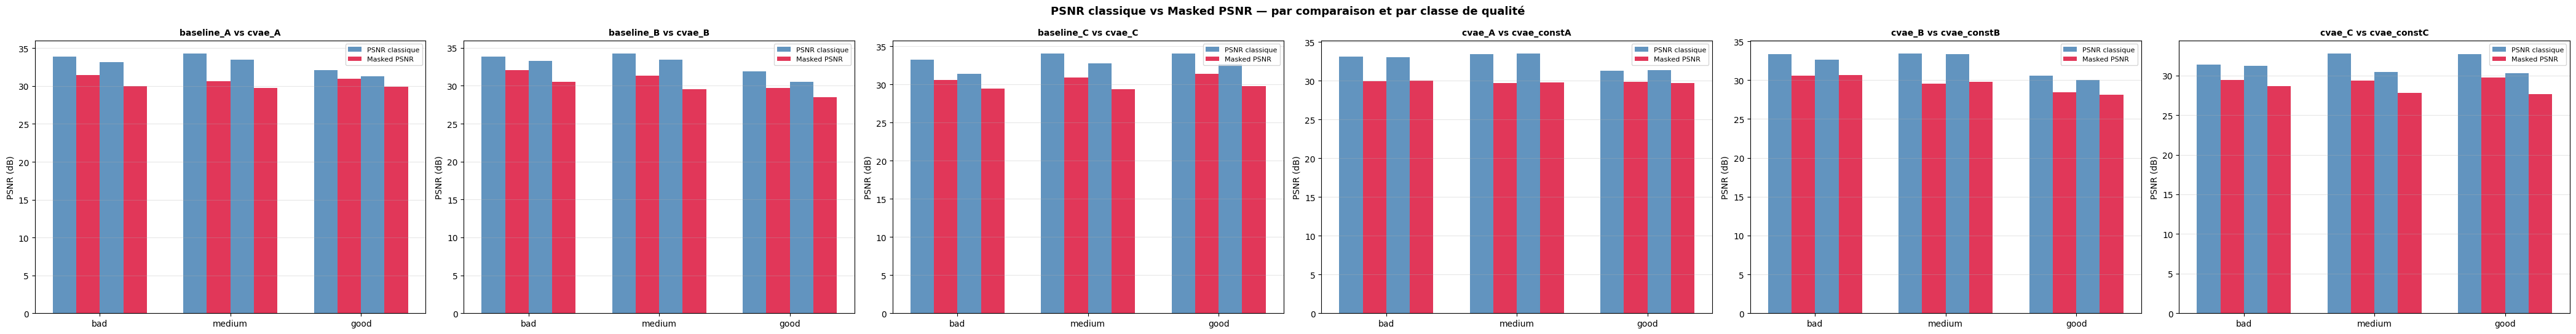

In [13]:
n_cmp = len(comparisons)
fig, axes = plt.subplots(1, n_cmp, figsize=(7 * n_cmp, 5.5), squeeze=False)
axes = axes[0]

for ax, cmp in zip(axes, comparisons):
    sub_all = df_psnr_table[df_psnr_table["comparaison"] == cmp["name"]]
    model_pair = [cmp["base_name"], cmp["cvae_name"]]
    x_pos = np.arange(len(label_order))
    width = 0.18
    for i, name in enumerate(model_pair):
        sub = sub_all[sub_all["model"] == name].set_index("quality_label").reindex(label_order)
        offset = (i - 0.5) * 2 * width
        ax.bar(x_pos + offset - width/2, sub["psnr_classique"], width, color="steelblue", alpha=0.85,
               label="PSNR classique" if i == 0 else None)
        ax.bar(x_pos + offset + width/2, sub["masked_psnr"], width, color="crimson", alpha=0.85,
               label="Masked PSNR" if i == 0 else None)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(label_order)
    ax.set_title(cmp["name"], fontsize=10, fontweight="bold")
    ax.set_ylabel("PSNR (dB)")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("PSNR classique vs Masked PSNR — par comparaison et par classe de qualité", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_psnr_vs_masked_bars.png", dpi=130, bbox_inches="tight")
plt.show()

### 8b. Le Masked PSNR change-t-il les conclusions ?

Pour chaque comparaison et chaque classe, on regarde si le gagnant change selon la métrique utilisée.

In [14]:
verdict_rows = []
for cmp in comparisons:
    df_cmp = cmp["df"]
    for label in label_order:
        sub = df_cmp[df_cmp["quality_label"] == label]
        if len(sub) == 0:
            continue
        mb_classic, mc_classic = sub["base_psnr"].mean(), sub["cvae_psnr"].mean()
        winner_classic = cmp["cvae_name"] if mc_classic > mb_classic else cmp["base_name"]

        mb_masked, mc_masked = sub["base_masked_psnr"].mean(), sub["cvae_masked_psnr"].mean()
        winner_masked = cmp["cvae_name"] if mc_masked > mb_masked else cmp["base_name"]

        verdict_rows.append({
            "comparaison": cmp["name"],
            "classe": label,
            "PSNR classique (base)": round(mb_classic, 3),
            "PSNR classique (cvae)": round(mc_classic, 3),
            "gagnant (classique)": winner_classic,
            "Masked PSNR (base)": round(mb_masked, 3),
            "Masked PSNR (cvae)": round(mc_masked, 3),
            "gagnant (masked)": winner_masked,
            "conclusion changée ?": "OUI" if winner_classic != winner_masked else "non",
        })

df_verdict = pd.DataFrame(verdict_rows)
df_verdict.to_csv(TABLES_DIR / "07_verdict_flip_table.csv", index=False)
df_verdict

,comparaison,classe,PSNR classique (base),PSNR classique (cvae),gagnant (classique),Masked PSNR (base),Masked PSNR (cvae),gagnant (masked),conclusion changée ?
0,baseline_A vs cvae_A,bad,33.870,33.133,baseline_A,31.417,29.961,baseline_A,non
1,baseline_A vs cvae_A,medium,34.302,33.466,baseline_A,30.615,29.715,baseline_A,non
2,baseline_A vs cvae_A,good,32.110,31.323,baseline_A,30.965,29.886,baseline_A,non
3,baseline_B vs cvae_B,bad,33.826,33.316,baseline_B,32.071,30.551,baseline_B,non
4,baseline_B vs cvae_B,medium,34.257,33.434,baseline_B,31.325,29.565,baseline_B,non
5,baseline_B vs cvae_B,good,31.891,30.543,baseline_B,29.718,28.477,baseline_B,non
6,baseline_C vs cvae_C,bad,33.201,31.382,baseline_C,30.565,29.422,baseline_C,non
7,baseline_C vs cvae_C,medium,34.018,32.768,baseline_C,30.868,29.336,baseline_C,non
8,baseline_C vs cvae_C,good,34.050,32.711,baseline_C,31.366,29.746,baseline_C,non
9,cvae_A vs cvae_constA,bad,33.133,32.997,cvae_A,29.961,30.037,cvae_constA,OUI


### 8c. Corrélation par image — PSNR classique vs Masked PSNR

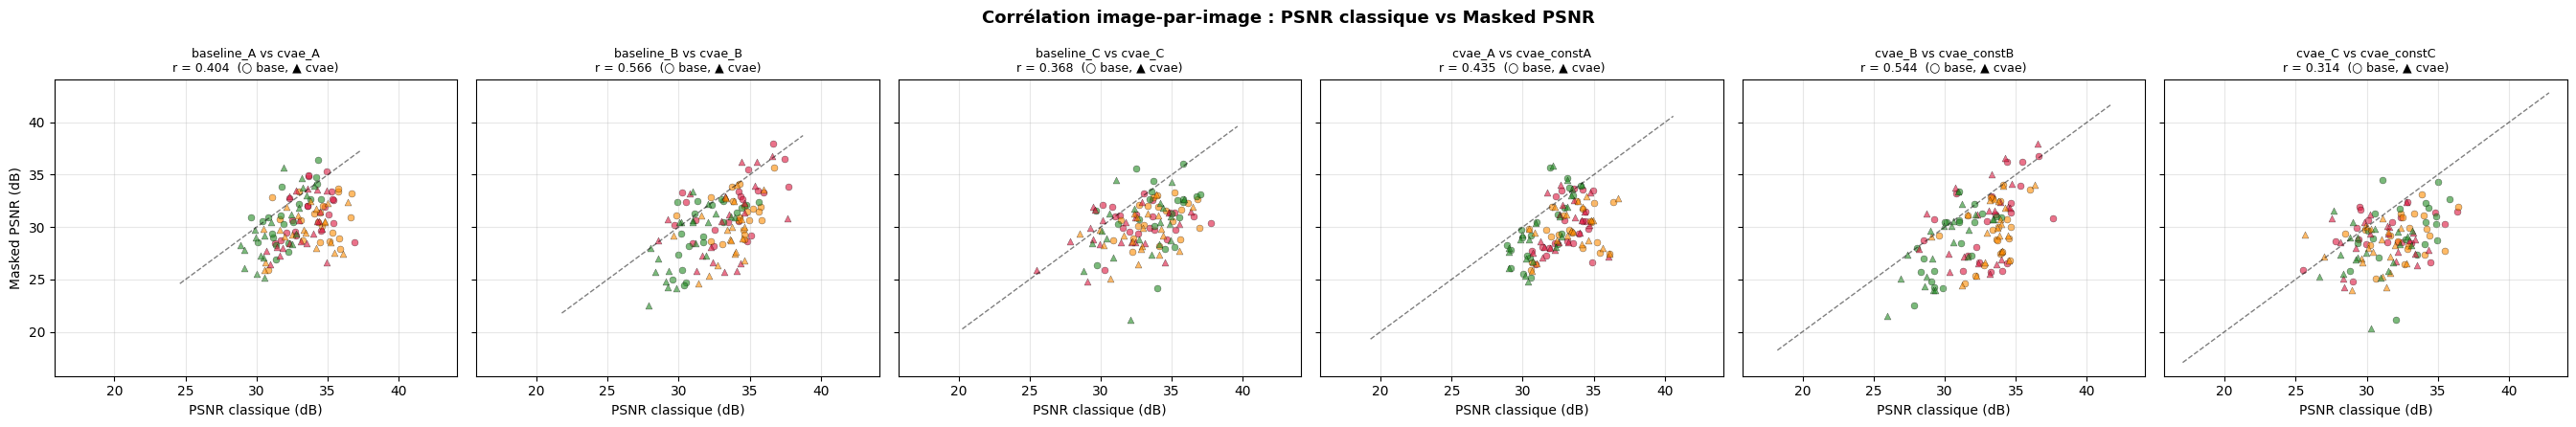

In [15]:
n_cmp = len(comparisons)
fig, axes = plt.subplots(1, n_cmp, figsize=(4.5 * n_cmp, 4.5), sharex=True, sharey=True, squeeze=False)
axes = axes[0]
label_colors = {"bad": "crimson", "medium": "darkorange", "good": "forestgreen"}

for ax, cmp in zip(axes, comparisons):
    df_cmp = cmp["df"]
    for role, name in [("base", cmp["base_name"]), ("cvae", cmp["cvae_name"])]:
        for label in label_order:
            sub = df_cmp[df_cmp["quality_label"] == label]
            ax.scatter(sub[f"{role}_psnr"], sub[f"{role}_masked_psnr"],
                       c=label_colors[label], alpha=0.6, s=25, edgecolors="k", lw=0.3,
                       marker="o" if role == "base" else "^")
    all_psnr = pd.concat([df_cmp["base_psnr"], df_cmp["cvae_psnr"]])
    all_mpsnr = pd.concat([df_cmp["base_masked_psnr"], df_cmp["cvae_masked_psnr"]])
    r = np.corrcoef(all_psnr, all_mpsnr)[0, 1]
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.5)
    ax.set_title(f"{cmp['name']}\nr = {r:.3f}  (○ base, ▲ cvae)", fontsize=9)
    ax.set_xlabel("PSNR classique (dB)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Masked PSNR (dB)")
fig.suptitle("Corrélation image-par-image : PSNR classique vs Masked PSNR", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_psnr_correlation_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Boxplots de distribution — comparaison directe base vs cVAE

Distinct pour PSNR classique et Masked PSNR, pour visualiser si le Masked PSNR
révèle un écart plus net entre les modèles.

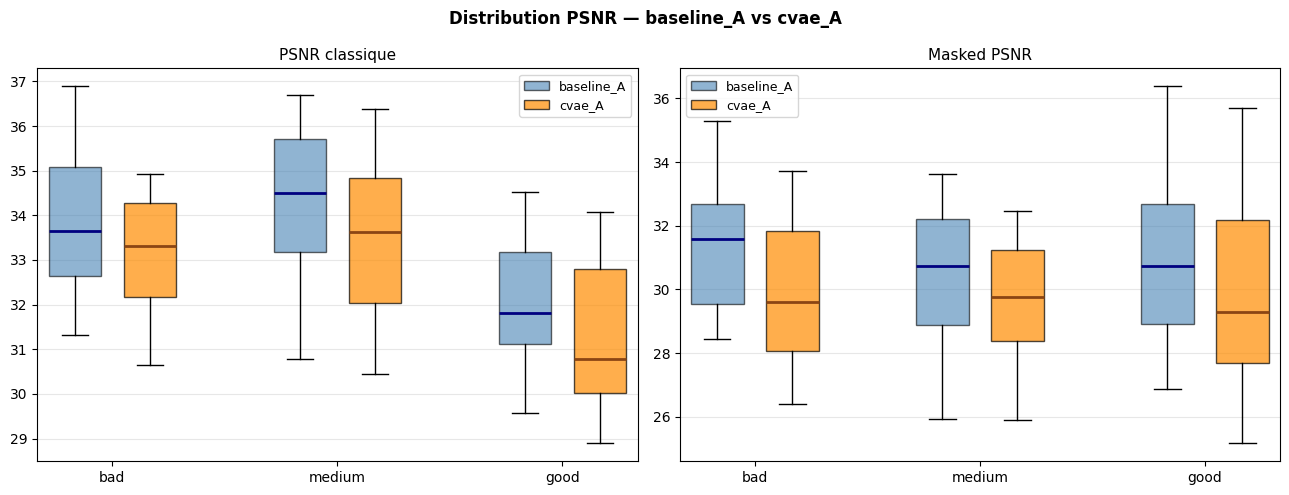

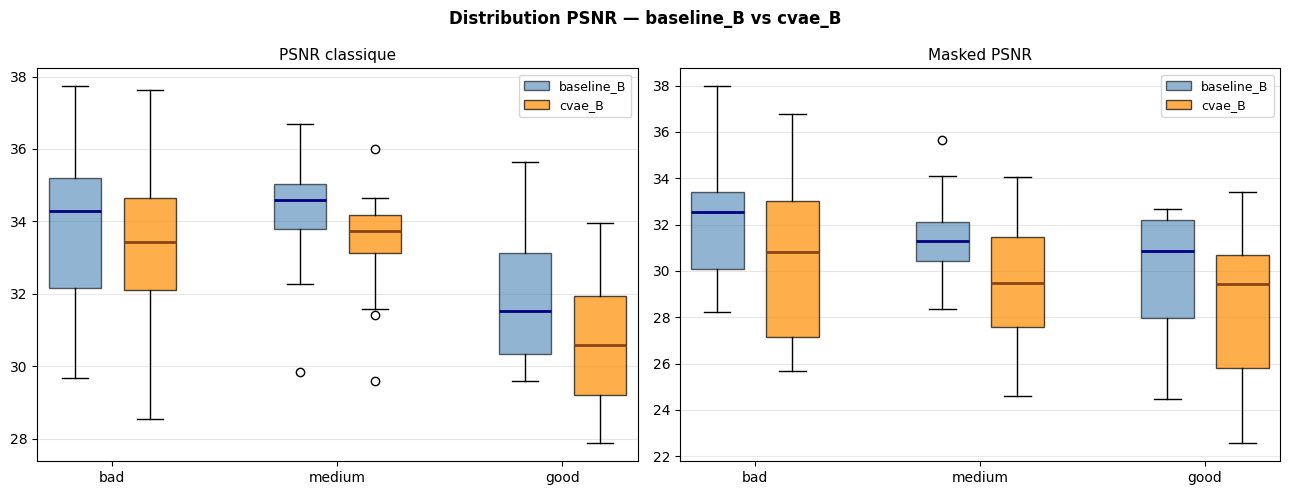

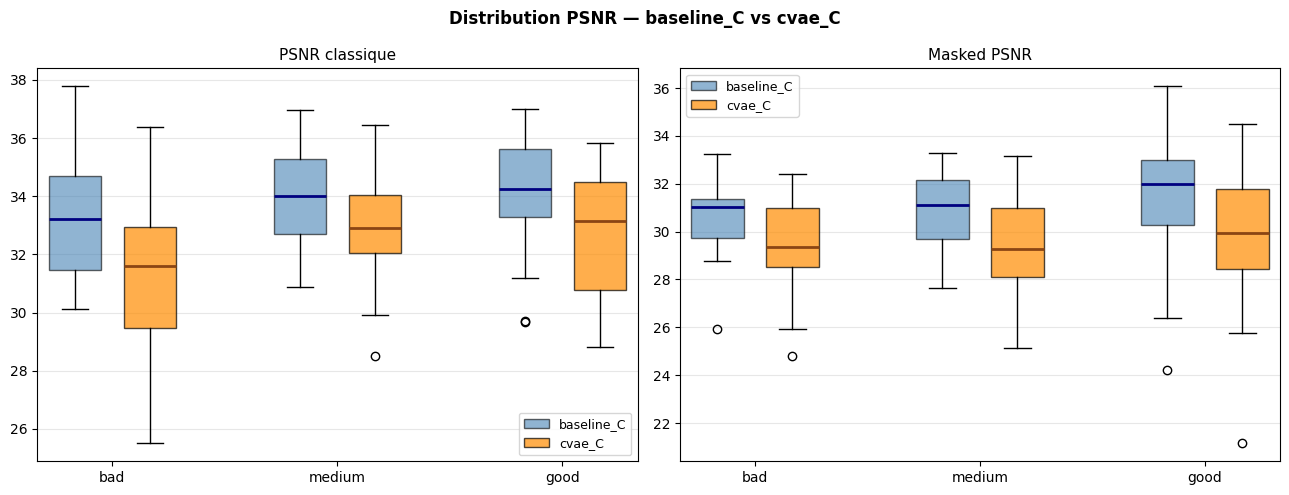

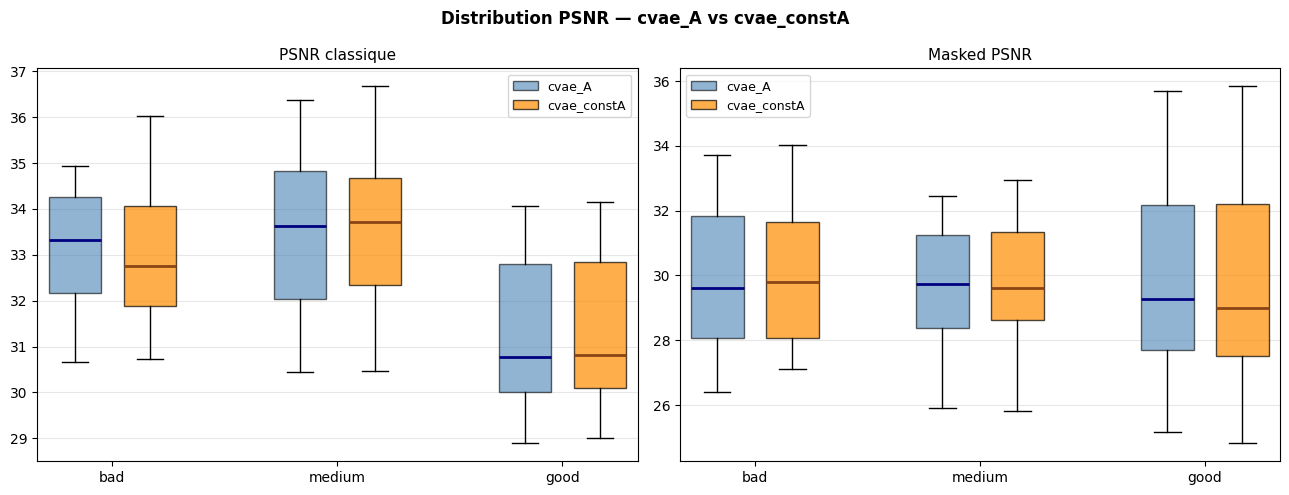

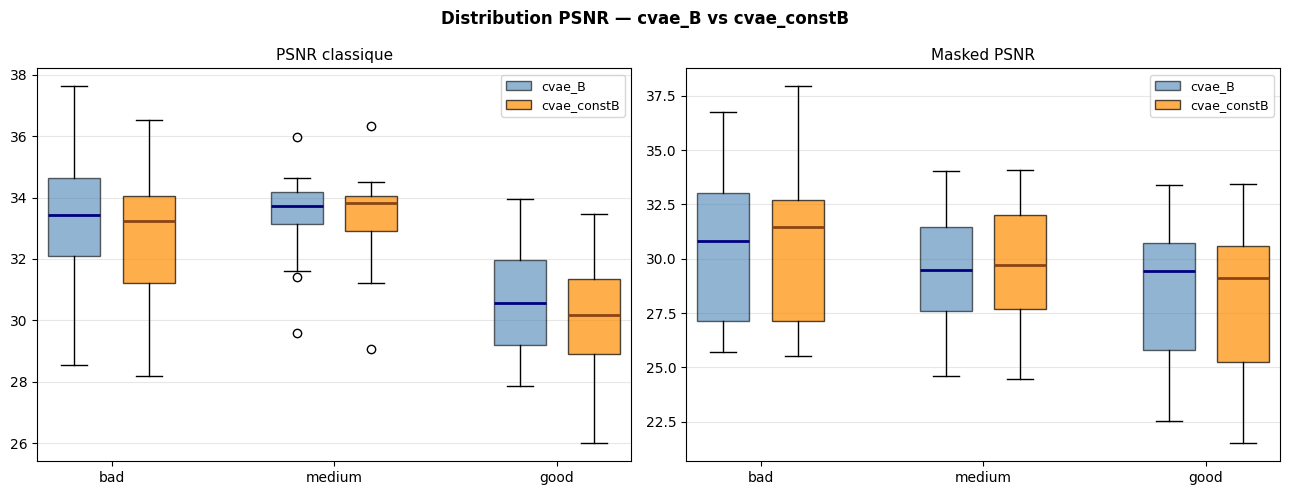

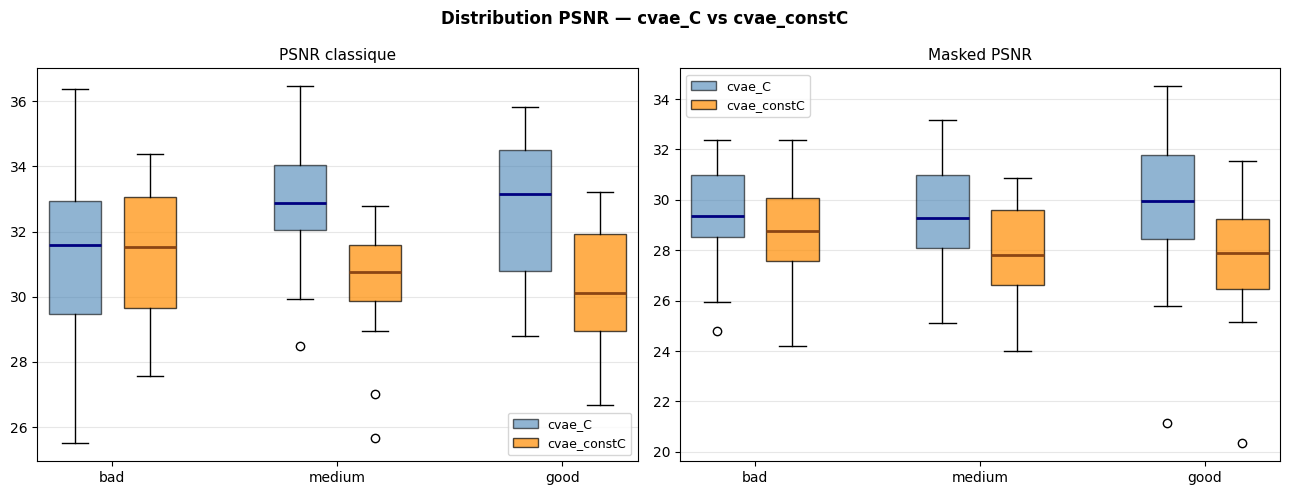

In [16]:
def boxplot_comparison(df_cmp: pd.DataFrame, base_name: str, cvae_name: str, suffix: str):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, metric, title in zip(axes, ["psnr", "masked_psnr"], ["PSNR classique", "Masked PSNR"]):
        data_b, data_c, positions_b, positions_c = [], [], [], []
        for i, label in enumerate(label_order):
            sub = df_cmp[df_cmp["quality_label"] == label]
            data_b.append(sub[f"base_{metric}"].values)
            data_c.append(sub[f"cvae_{metric}"].values)
            positions_b.append(i * 3)
            positions_c.append(i * 3 + 1)
        bp1 = ax.boxplot(data_b, positions=positions_b, widths=0.7, patch_artist=True,
                          boxprops=dict(facecolor="steelblue", alpha=0.6), medianprops=dict(color="navy", lw=2))
        bp2 = ax.boxplot(data_c, positions=positions_c, widths=0.7, patch_artist=True,
                          boxprops=dict(facecolor="darkorange", alpha=0.7), medianprops=dict(color="saddlebrown", lw=2))
        ax.set_xticks([i * 3 + 0.5 for i in range(len(label_order))])
        ax.set_xticklabels(label_order)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        ax.legend([bp1["boxes"][0], bp2["boxes"][0]], [base_name, cvae_name], fontsize=9)
    fig.suptitle(f"Distribution PSNR — {base_name} vs {cvae_name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"07_boxplots_{suffix}.png", dpi=130, bbox_inches="tight")
    plt.show()


for cmp in comparisons:
    suffix = cmp["approach"] if cmp["approach"].startswith("ablation") else f"approach_{cmp['approach']}"
    boxplot_comparison(cmp["df"], cmp["base_name"], cmp["cvae_name"], suffix)

## 10. Tests statistiques (Wilcoxon) — PSNR classique vs Masked PSNR

In [17]:
def wilcoxon_table(df_cmp: pd.DataFrame, base_name: str, cvae_name: str):
    print("=" * 90)
    print(f"{base_name}  vs  {cvae_name}")
    print("=" * 90)
    for metric, mlabel in [("psnr", "PSNR classique"), ("masked_psnr", "Masked PSNR")]:
        print(f"\n  {mlabel} (↑ meilleur)")
        print(f"  {'Classe':8s}  {base_name:>14s}  {cvae_name:>14s}  {'Δ':>10s}  {'p-value':>10s}  verdict")
        for label in label_order:
            sub = df_cmp[df_cmp["quality_label"] == label]
            if len(sub) < 2:
                continue
            vb, vc = sub[f"base_{metric}"].values, sub[f"cvae_{metric}"].values
            mb, mc = vb.mean(), vc.mean()
            try:
                _, pval = stats.wilcoxon(vb, vc)
            except Exception:
                pval = float("nan")
            sig = "sig." if (not np.isnan(pval) and pval < 0.05) else "n.s."
            winner = cvae_name if mc > mb else base_name
            print(f"  {label:8s}  {mb:14.4f}  {mc:14.4f}  {mc-mb:+10.4f}  {pval:10.4f}  {sig:5s} -> {winner}")


for cmp in comparisons:
    wilcoxon_table(cmp["df"], cmp["base_name"], cmp["cvae_name"])

baseline_A  vs  cvae_A

  PSNR classique (↑ meilleur)
  Classe        baseline_A          cvae_A           Δ     p-value  verdict
  bad              33.8702         33.1330     -0.7372      0.0001  sig.  -> baseline_A
  medium           34.3018         33.4664     -0.8354      0.0000  sig.  -> baseline_A
  good             32.1105         31.3231     -0.7874      0.0020  sig.  -> baseline_A

  Masked PSNR (↑ meilleur)
  Classe        baseline_A          cvae_A           Δ     p-value  verdict
  bad              31.4171         29.9611     -1.4560      0.0000  sig.  -> baseline_A
  medium           30.6152         29.7149     -0.9003      0.0362  sig.  -> baseline_A
  good             30.9648         29.8864     -1.0784      0.0003  sig.  -> baseline_A
baseline_B  vs  cvae_B

  PSNR classique (↑ meilleur)
  Classe        baseline_B          cvae_B           Δ     p-value  verdict
  bad              33.8256         33.3160     -0.5096      0.0215  sig.  -> baseline_B
  medium           3

## 11. Dégradations synthétiques — PSNR classique vs Masked PSNR selon la sévérité

On dégrade artificiellement les meilleures images ARCADE (7 dégradations, comme le
Notebook 5) et on compare base vs cVAE sur les deux métriques, pour les 3 approches.

**Limite assumée :** pour ces images synthétiques, aucune approche ne dispose d'un
score précalculé (`score_weighted`/`score_pca`/`score_dl` n'existent que pour les
images réelles du dataset). On utilise donc, pour les 3 approches, le même proxy
générique `inline_quality_score` (heuristique Tenengrad + Laplacian, cf. Notebook 5)
comme valeur de conditionnement $c$ — ce n'est pas le score natif de chaque approche,
mais c'est la même approximation pour toutes, donc la comparaison base vs cVAE par
approche reste valide (aucun biais asymétrique introduit).

In [18]:
def add_gaussian_noise(x: torch.Tensor, sigma: float) -> torch.Tensor:
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)


def add_motion_blur(x: torch.Tensor, kernel_size: int, direction: str = "horizontal") -> torch.Tensor:
    if direction == "horizontal":
        k = torch.ones(1, 1, 1, kernel_size, device=x.device) / kernel_size
        pad = (kernel_size // 2, kernel_size // 2, 0, 0)
    else:
        k = torch.ones(1, 1, kernel_size, 1, device=x.device) / kernel_size
        pad = (0, 0, kernel_size // 2, kernel_size // 2)
    return F.conv2d(F.pad(x, pad, mode="reflect"), k).clamp(-1, 1)


DEGRADATION_GRID = [
    {"name": "Propre",        "fn": lambda x: x},
    {"name": "Bruit σ=0.05",  "fn": lambda x: add_gaussian_noise(x, 0.05)},
    {"name": "Bruit σ=0.10",  "fn": lambda x: add_gaussian_noise(x, 0.10)},
    {"name": "Bruit σ=0.20",  "fn": lambda x: add_gaussian_noise(x, 0.20)},
    {"name": "Flou H k=5",    "fn": lambda x: add_motion_blur(x, 5,  "horizontal")},
    {"name": "Flou V k=5",    "fn": lambda x: add_motion_blur(x, 5,  "vertical")},
    {"name": "Flou V k=11",   "fn": lambda x: add_motion_blur(x, 11, "vertical")},
]


def inline_quality_score(img_tensor: torch.Tensor) -> float:
    from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
    img = img_tensor.squeeze().cpu().numpy().astype(np.float64)
    img = (img + 1) / 2
    img_smooth = gaussian_filter(img, sigma=1.0)
    mu = uniform_filter(img_smooth, size=7)
    sigma = np.sqrt(np.maximum(uniform_filter(img_smooth**2, size=7) - mu**2, 0))
    mscn = (img_smooth - mu) / (sigma + 1.0)
    lap_var = float(laplace(mscn).var())
    Gx, Gy = sobel(mscn, axis=1), sobel(mscn, axis=0)
    tenengrad = float(np.sqrt(Gx**2 + Gy**2).mean())
    noise_energy = float(np.mean((img - img_smooth) ** 2))
    noise_penalty = float(np.clip(1.0 - noise_energy / 0.005, 0.0, 1.0))
    raw_score = np.clip(0.5 * (lap_var / 0.01) + 0.5 * (tenengrad / 0.5), 0.0, 1.0)
    return float(raw_score * noise_penalty)


ACTIVE_APPROACHES = [c["approach"] for c in comparisons if c["approach"] in ("A", "B", "C")]


@torch.no_grad()
def evaluate_synthetic_all(df_good: pd.DataFrame) -> pd.DataFrame:
    records = []
    for _, row in tqdm(df_good.iterrows(), total=len(df_good), desc="Synthetic", leave=False):
        path, split = row["path"], row["split"]
        try:
            x_clean = load_tensor(path).to(DEVICE)
        except Exception:
            continue
        for d in DEGRADATION_GRID:
            x_deg = d["fn"](x_clean)
            c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

            record = {"image_id": row["image_id"], "degradation": d["name"], "c_inline": float(c_deg.item())}
            for key in ACTIVE_APPROACHES:
                rec_base, _, _ = models[f"baseline_{key}"](x_deg, sample_posterior=False, decode=True)
                rec_cvae, _ = models[f"cvae_{key}"](x_deg, c_deg, sample_posterior=False)
                m_base = compute_all_metrics(x_clean, rec_base, path, split)
                m_cvae = compute_all_metrics(x_clean, rec_cvae, path, split)
                record.update({f"base_{key}_{k}": v for k, v in m_base.items()})
                record.update({f"cvae_{key}_{k}": v for k, v in m_cvae.items()})
                const_name = f"cvae_const{key}"
                if const_name in models:
                    rec_const, _ = models[const_name](x_deg, c_deg, sample_posterior=False)
                    m_const = compute_all_metrics(x_clean, rec_const, path, split)
                    record.update({f"const_{key}_{k}": v for k, v in m_const.items()})
            records.append(record)
    return pd.DataFrame(records)


# Images "good" de référence pour le benchmark synthétique : on prend la première
# approche disponible (pas forcément B — toutes les approches partagent les mêmes
# images, seul le score qui les sélectionne diffère légèrement).
_SYNTH_REF_KEY = ACTIVE_APPROACHES[0] if ACTIVE_APPROACHES else None
if _SYNTH_REF_KEY is None:
    raise RuntimeError("Aucune approche disponible (aucun checkpoint NB04 trouvé) — impossible d'évaluer le benchmark synthétique.")

df_synth = evaluate_synthetic_all(test_sets_by_approach[_SYNTH_REF_KEY]["good"])
df_synth.to_csv(TABLES_DIR / "07_synthetic_results.csv", index=False)
print(f"Images synthétiques évaluées : {len(df_synth)} entrées")

Images synthétiques évaluées : 140 entrées


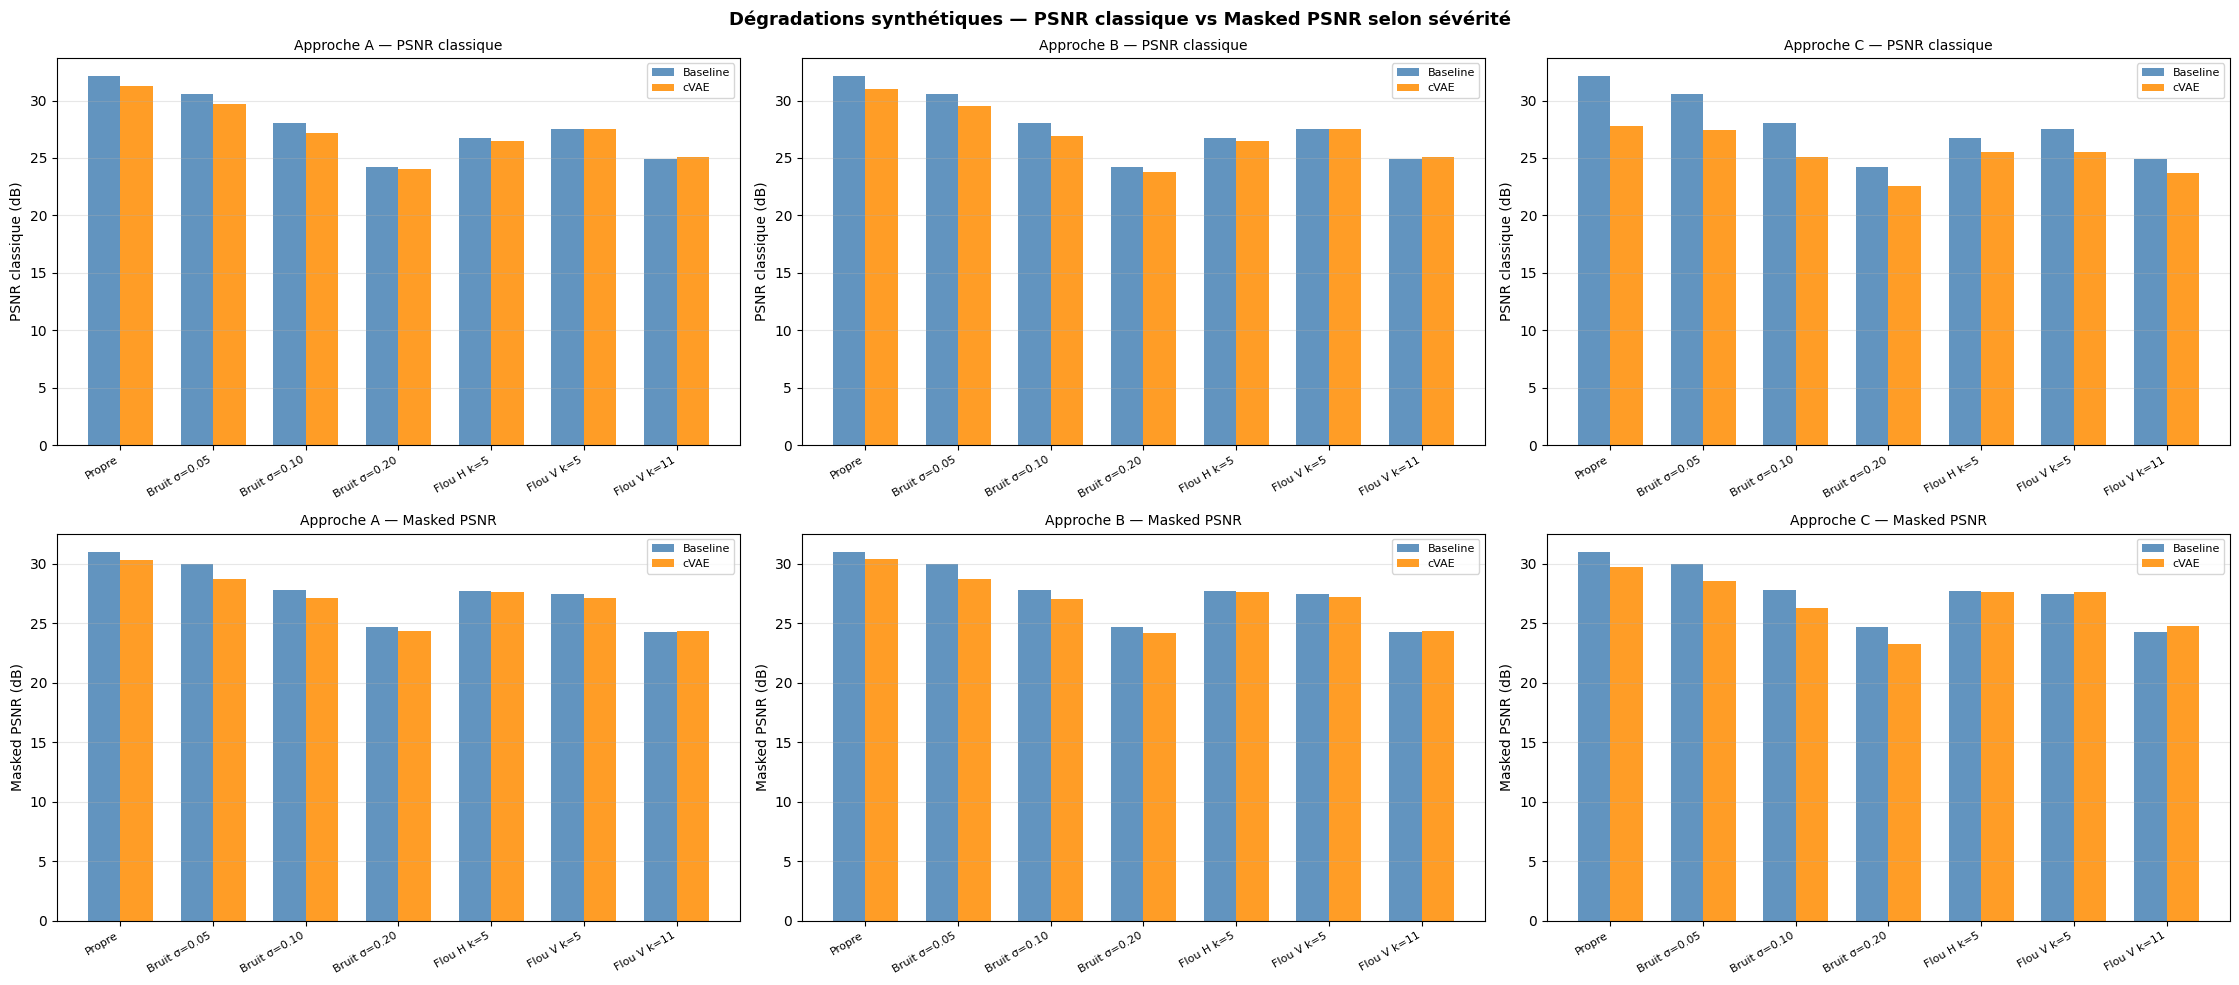

In [19]:
order = [d["name"] for d in DEGRADATION_GRID]
n_app = len(ACTIVE_APPROACHES)

fig, axes = plt.subplots(2, n_app, figsize=(7.5 * n_app, 10), squeeze=False)

for col, key in enumerate(ACTIVE_APPROACHES):
    for row, (metric, ylabel) in enumerate([("psnr", "PSNR classique (dB)"), ("masked_psnr", "Masked PSNR (dB)")]):
        ax = axes[row, col]
        g = df_synth.groupby("degradation")[[f"base_{key}_{metric}", f"cvae_{key}_{metric}"]].mean().reindex(order)
        x_pos = np.arange(len(order))
        width = 0.35
        ax.bar(x_pos - width/2, g[f"base_{key}_{metric}"], width, label="Baseline", color="steelblue", alpha=0.85)
        ax.bar(x_pos + width/2, g[f"cvae_{key}_{metric}"], width, label="cVAE", color="darkorange", alpha=0.85)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Approche {key} — {ylabel.split('(')[0].strip()}", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

fig.suptitle("Dégradations synthétiques — PSNR classique vs Masked PSNR selon sévérité", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_synthetic_psnr_vs_masked.png", dpi=130, bbox_inches="tight")
plt.show()

## 12. Galeries qualitatives — comparaison à l'œil

Pour chaque approche, on affiche les reconstructions de son propre jeu de test "bad"
(avec overlay du masque vasculaire) pour juger visuellement, même si les métriques
globales ne distinguent pas toujours les modèles. PSNR classique et Masked PSNR sont
annotés sous chaque image.

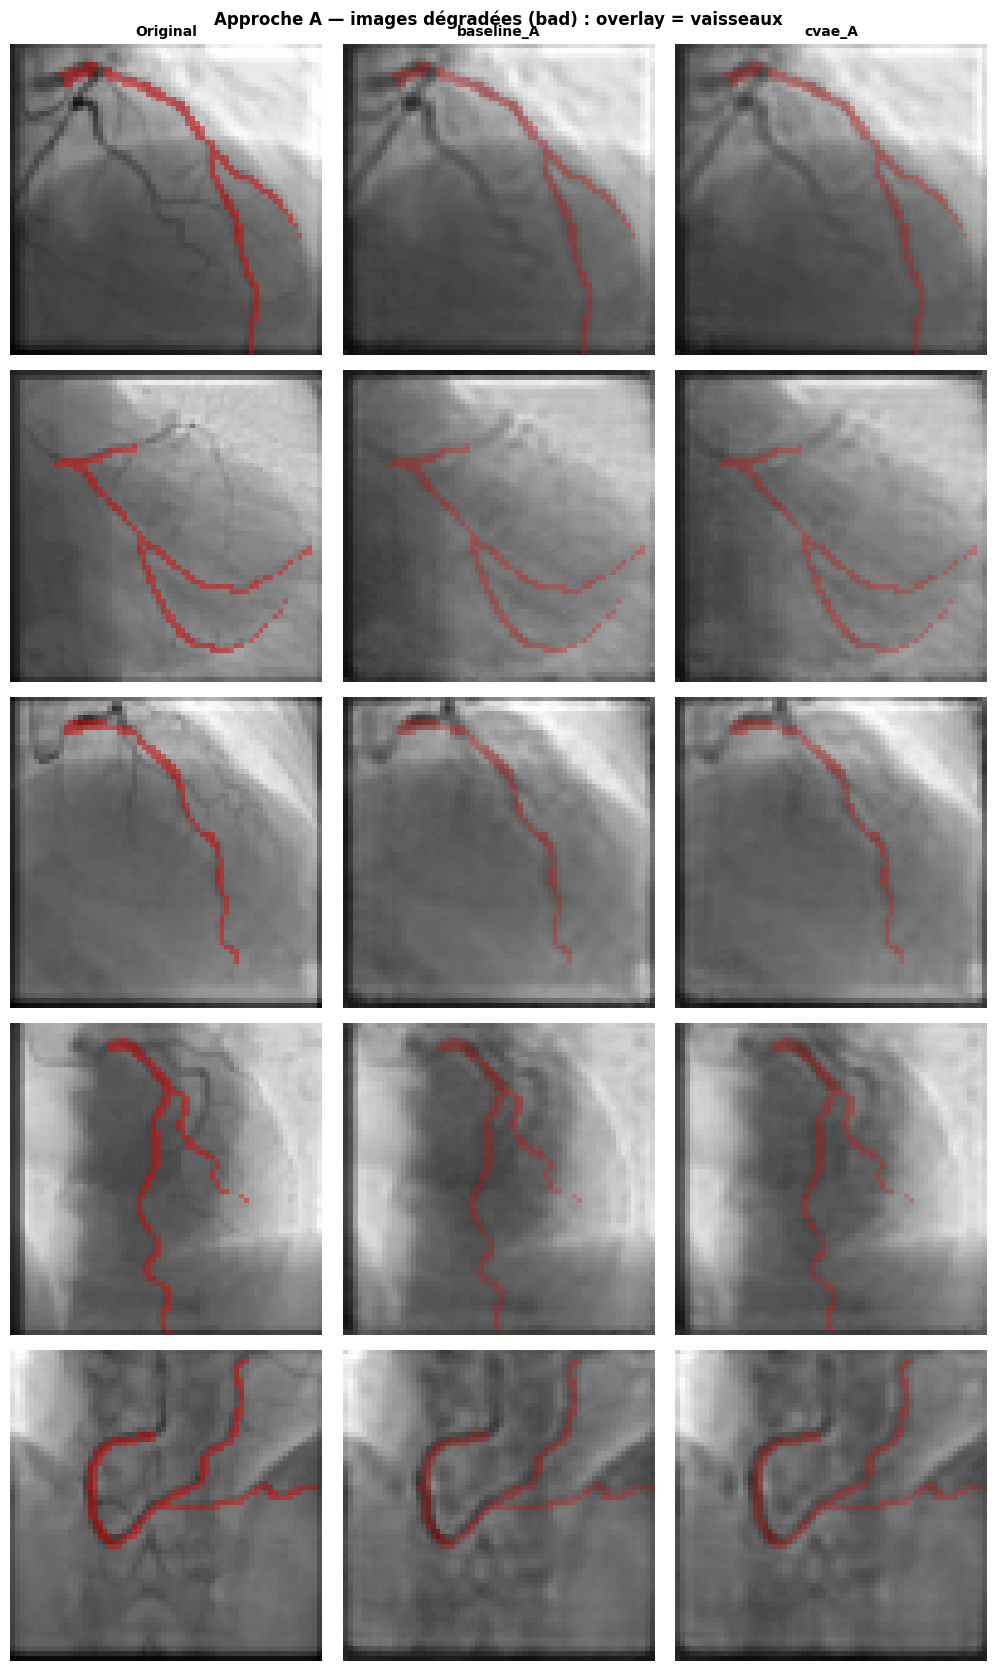

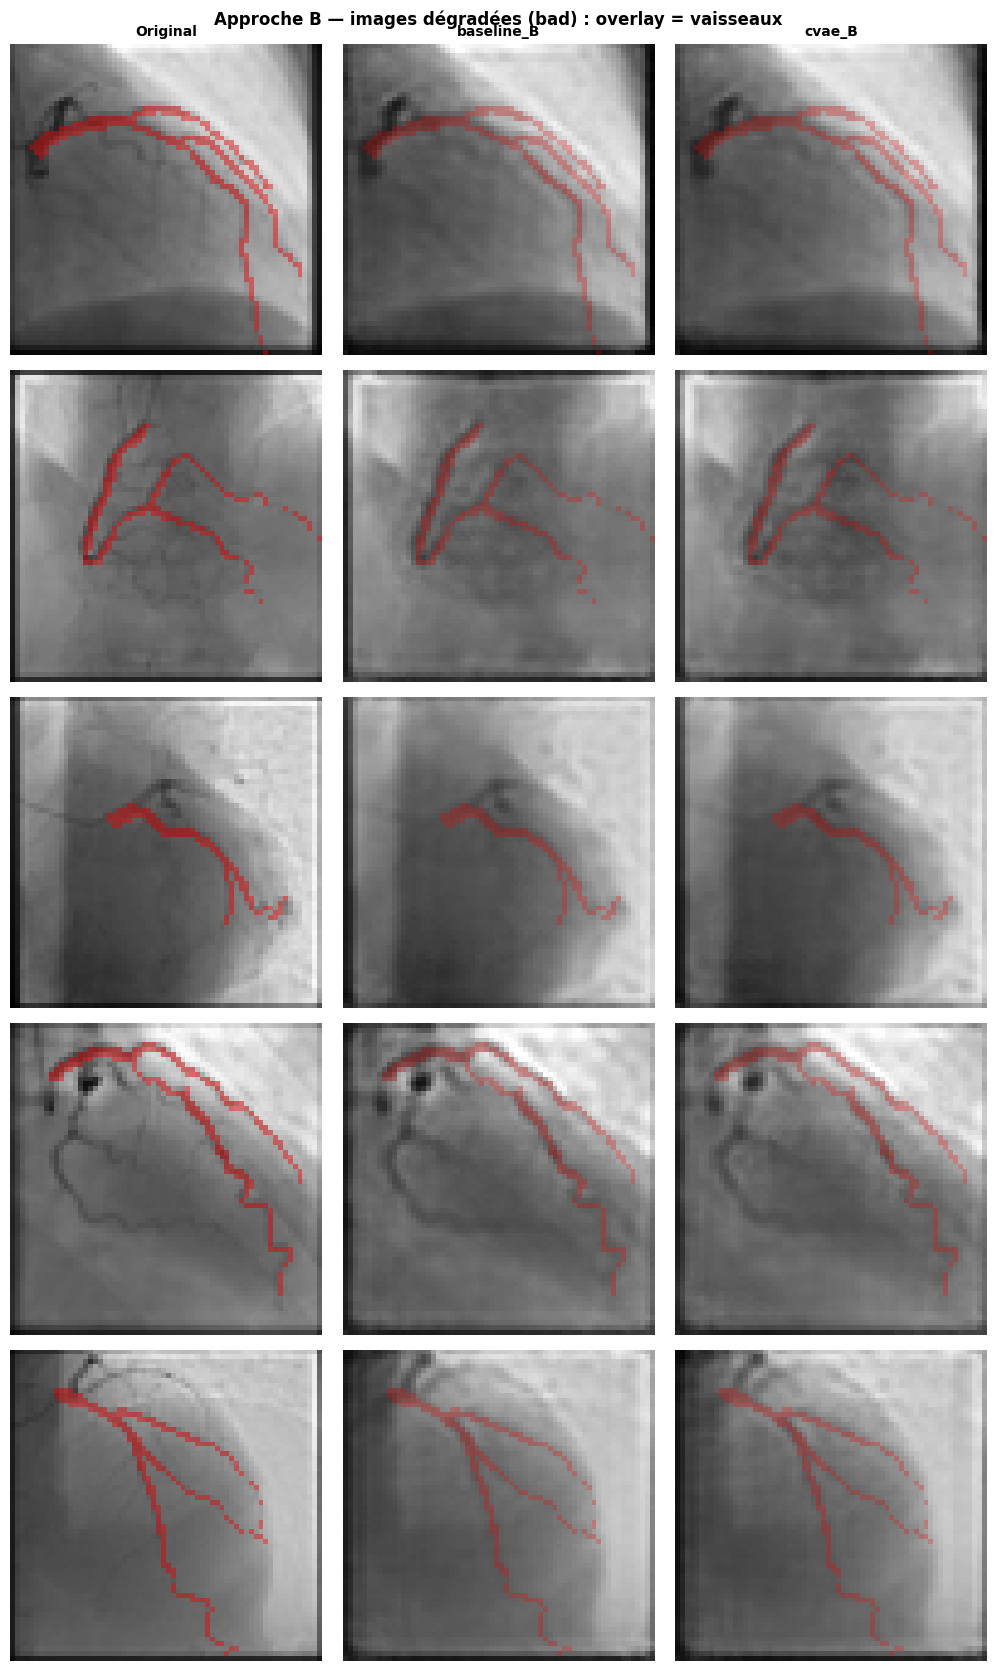

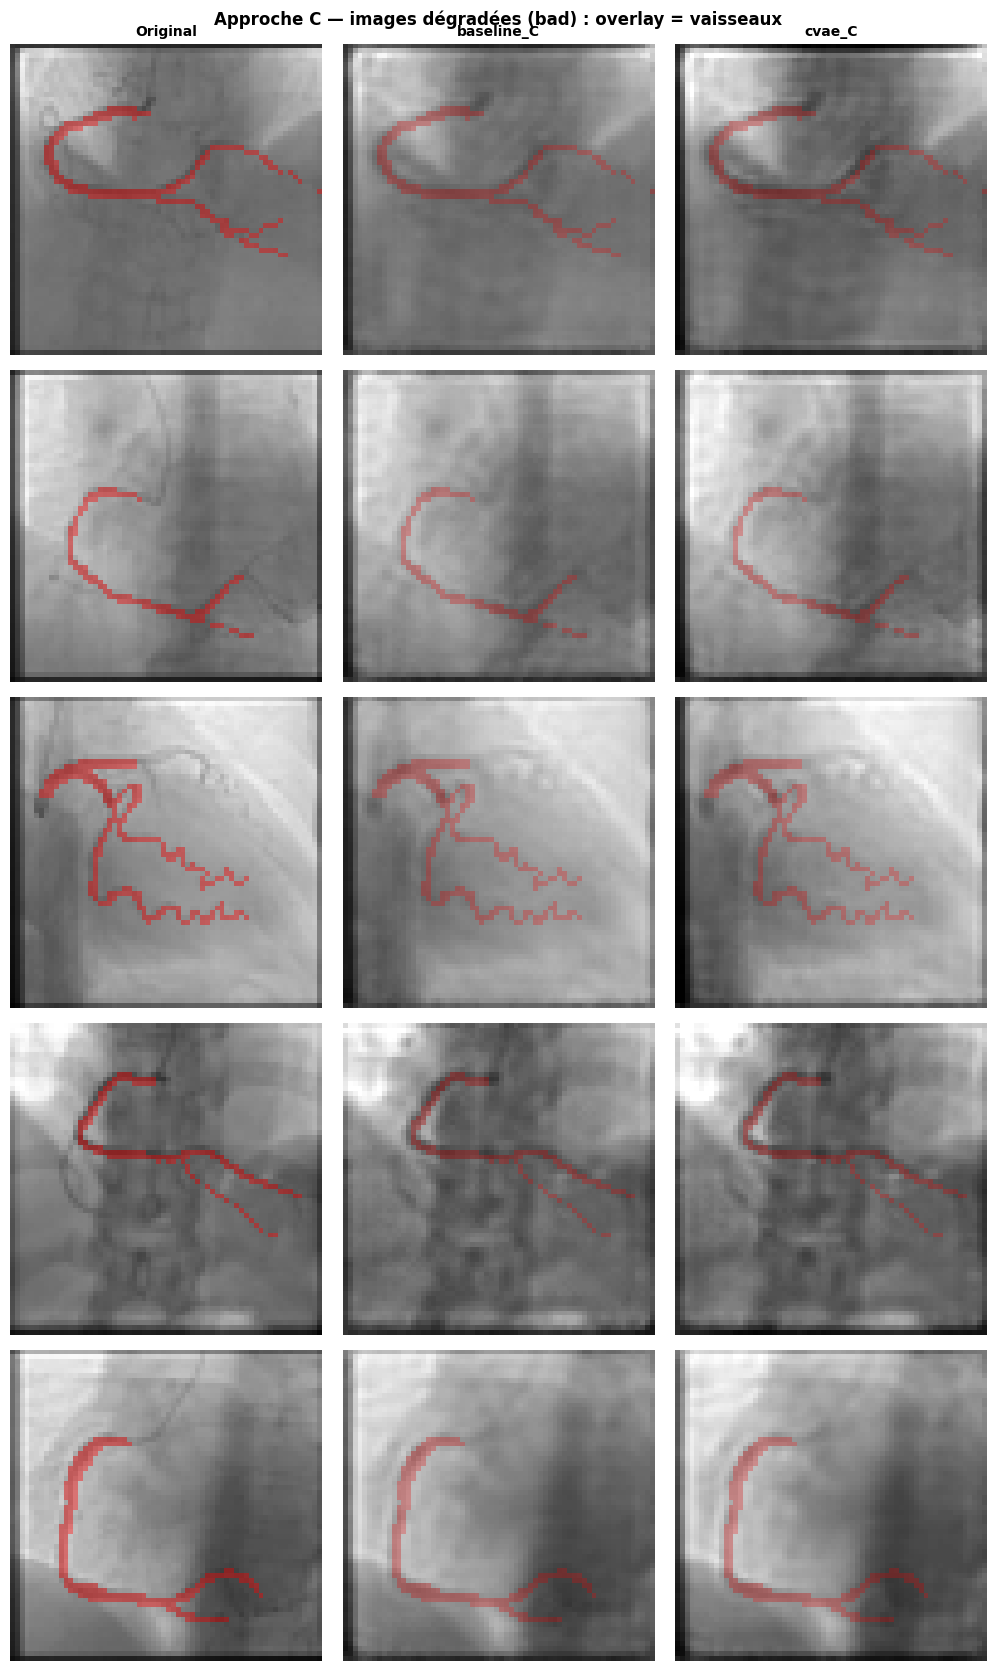

In [20]:
@torch.no_grad()
def build_gallery_pair(df_sub: pd.DataFrame, score_col: str, base_name: str, cvae_name: str,
                        n: int, title: str, fname: str):
    rows_df = df_sub.sort_values(score_col).head(n)
    model_keys = [base_name, cvae_name]
    n_cols = 1 + len(model_keys)

    fig, axes = plt.subplots(len(rows_df), n_cols, figsize=(3.4 * n_cols, 3.4 * len(rows_df)))
    if len(rows_df) == 1:
        axes = axes[np.newaxis, :]

    for ax, ct in zip(axes[0], ["Original"] + model_keys):
        ax.set_title(ct, fontsize=10, fontweight="bold")

    for row_idx, (_, record) in enumerate(rows_df.iterrows()):
        path, split = record["path"], record["split"]
        x = load_tensor(path).to(DEVICE)
        c = torch.tensor([record[score_col]], device=DEVICE)
        orig_np = to_uint8(x)
        mask64 = masked_mask_for(path, split, size=IMG_SIZE)

        axes[row_idx, 0].imshow(orig_np, cmap="gray", vmin=0, vmax=255)
        axes[row_idx, 0].imshow(np.ma.masked_where(mask64 == 0, mask64), cmap="autumn", alpha=0.4)
        axes[row_idx, 0].axis("off")
        axes[row_idx, 0].set_ylabel(f"c={record[score_col]:.2f}", fontsize=8)

        for col, name in enumerate(model_keys, start=1):
            model = models[name]
            if name.startswith("baseline"):
                rec_out, _, _ = model(x, sample_posterior=False, decode=True)
            else:
                rec_out, _ = model(x, c, sample_posterior=False)
            rec_np = to_uint8(rec_out)
            m = compute_all_metrics(x, rec_out, path, split)

            axes[row_idx, col].imshow(rec_np, cmap="gray", vmin=0, vmax=255)
            axes[row_idx, col].imshow(np.ma.masked_where(mask64 == 0, mask64), cmap="autumn", alpha=0.25)
            axes[row_idx, col].axis("off")
            axes[row_idx, col].set_xlabel(f"PSNR={m['psnr']:.1f}  MPSNR={m['masked_psnr']:.1f}", fontsize=7.5)

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fname, dpi=130, bbox_inches="tight")
    plt.show()


for key in ACTIVE_APPROACHES:
    score_col = MODEL_SCORE_COL[f"cvae_{key}"]
    df_bad = test_sets_by_approach[key]["bad"]
    if len(df_bad) >= 3:
        build_gallery_pair(
            df_bad, score_col, f"baseline_{key}", f"cvae_{key}", n=5,
            title=f"Approche {key} — images dégradées (bad) : overlay = vaisseaux",
            fname=f"07_gallery_bad_approach_{key}.png",
        )

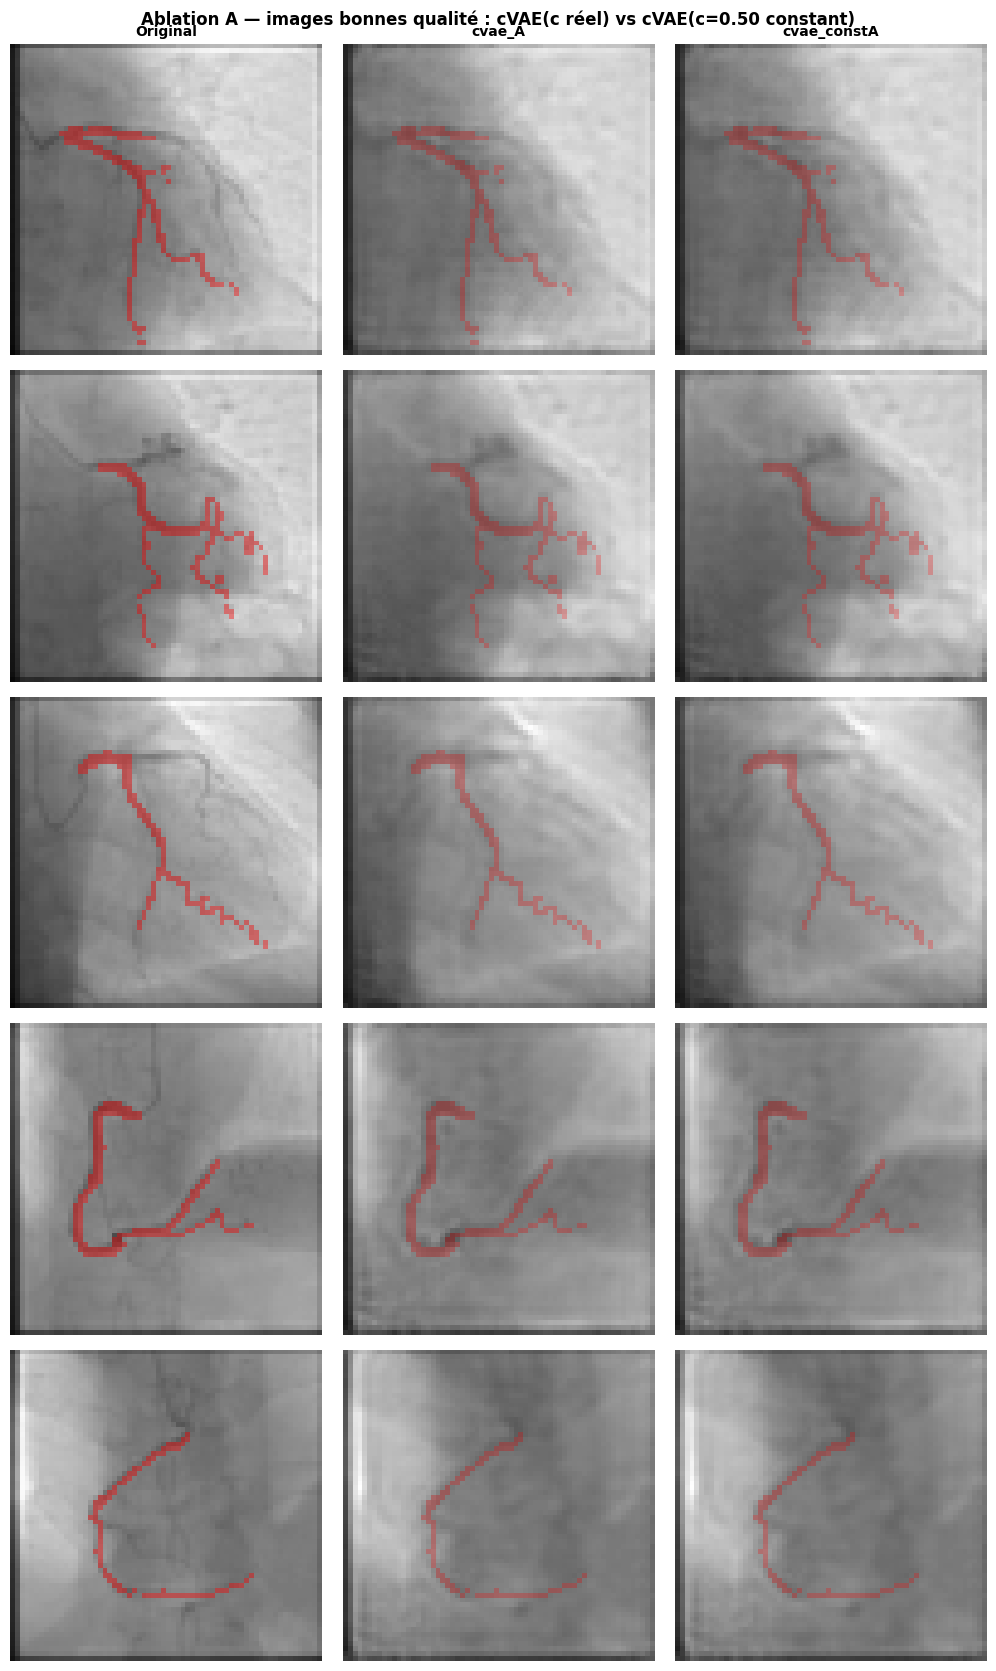

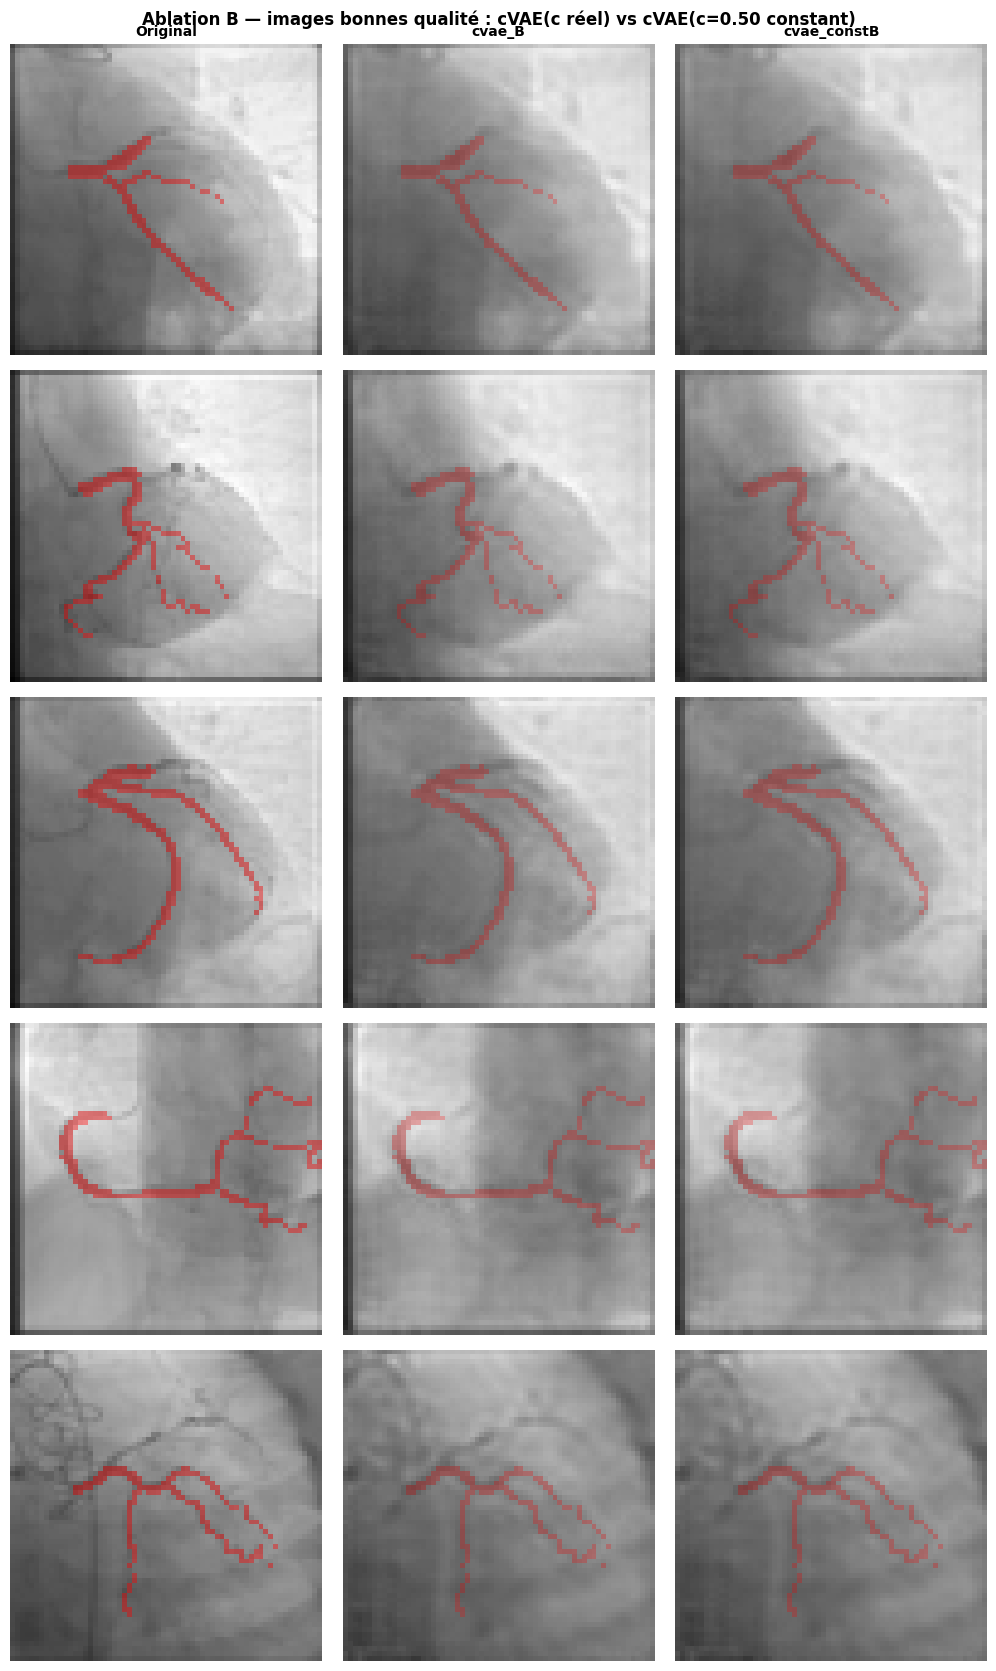

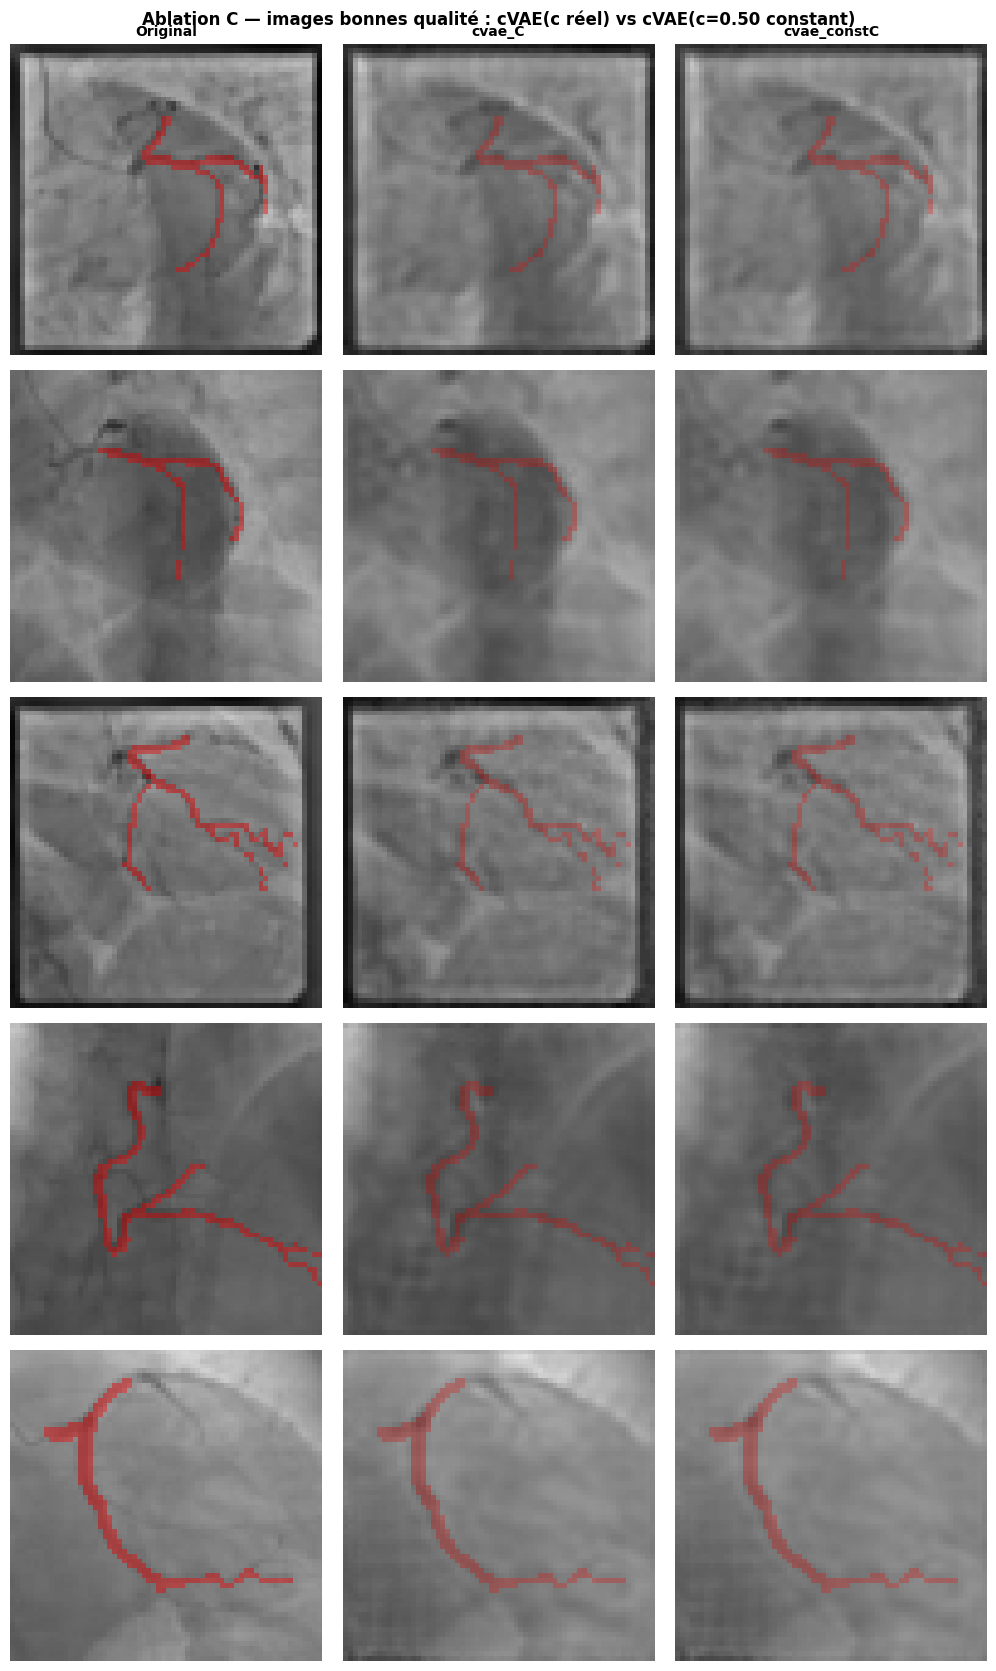

In [21]:
# Galerie ablation : cVAE(c réel) vs cVAE(c constant) — une par approche où NB06 est disponible
for key in ["A", "B", "C"]:
    const_name = f"cvae_const{key}"
    if const_name not in models or key not in test_sets_by_approach:
        continue
    score_col = MODEL_SCORE_COL[const_name]
    df_good = test_sets_by_approach[key]["good"]
    if len(df_good) >= 3:
        c_val = C_CONSTANT.get(key, 0.5)
        build_gallery_pair(
            df_good, score_col, f"cvae_{key}", const_name, n=5,
            title=f"Ablation {key} — images bonnes qualité : cVAE(c réel) vs cVAE(c={c_val:.2f} constant)",
            fname=f"07_gallery_good_ablation_{key}.png",
        )

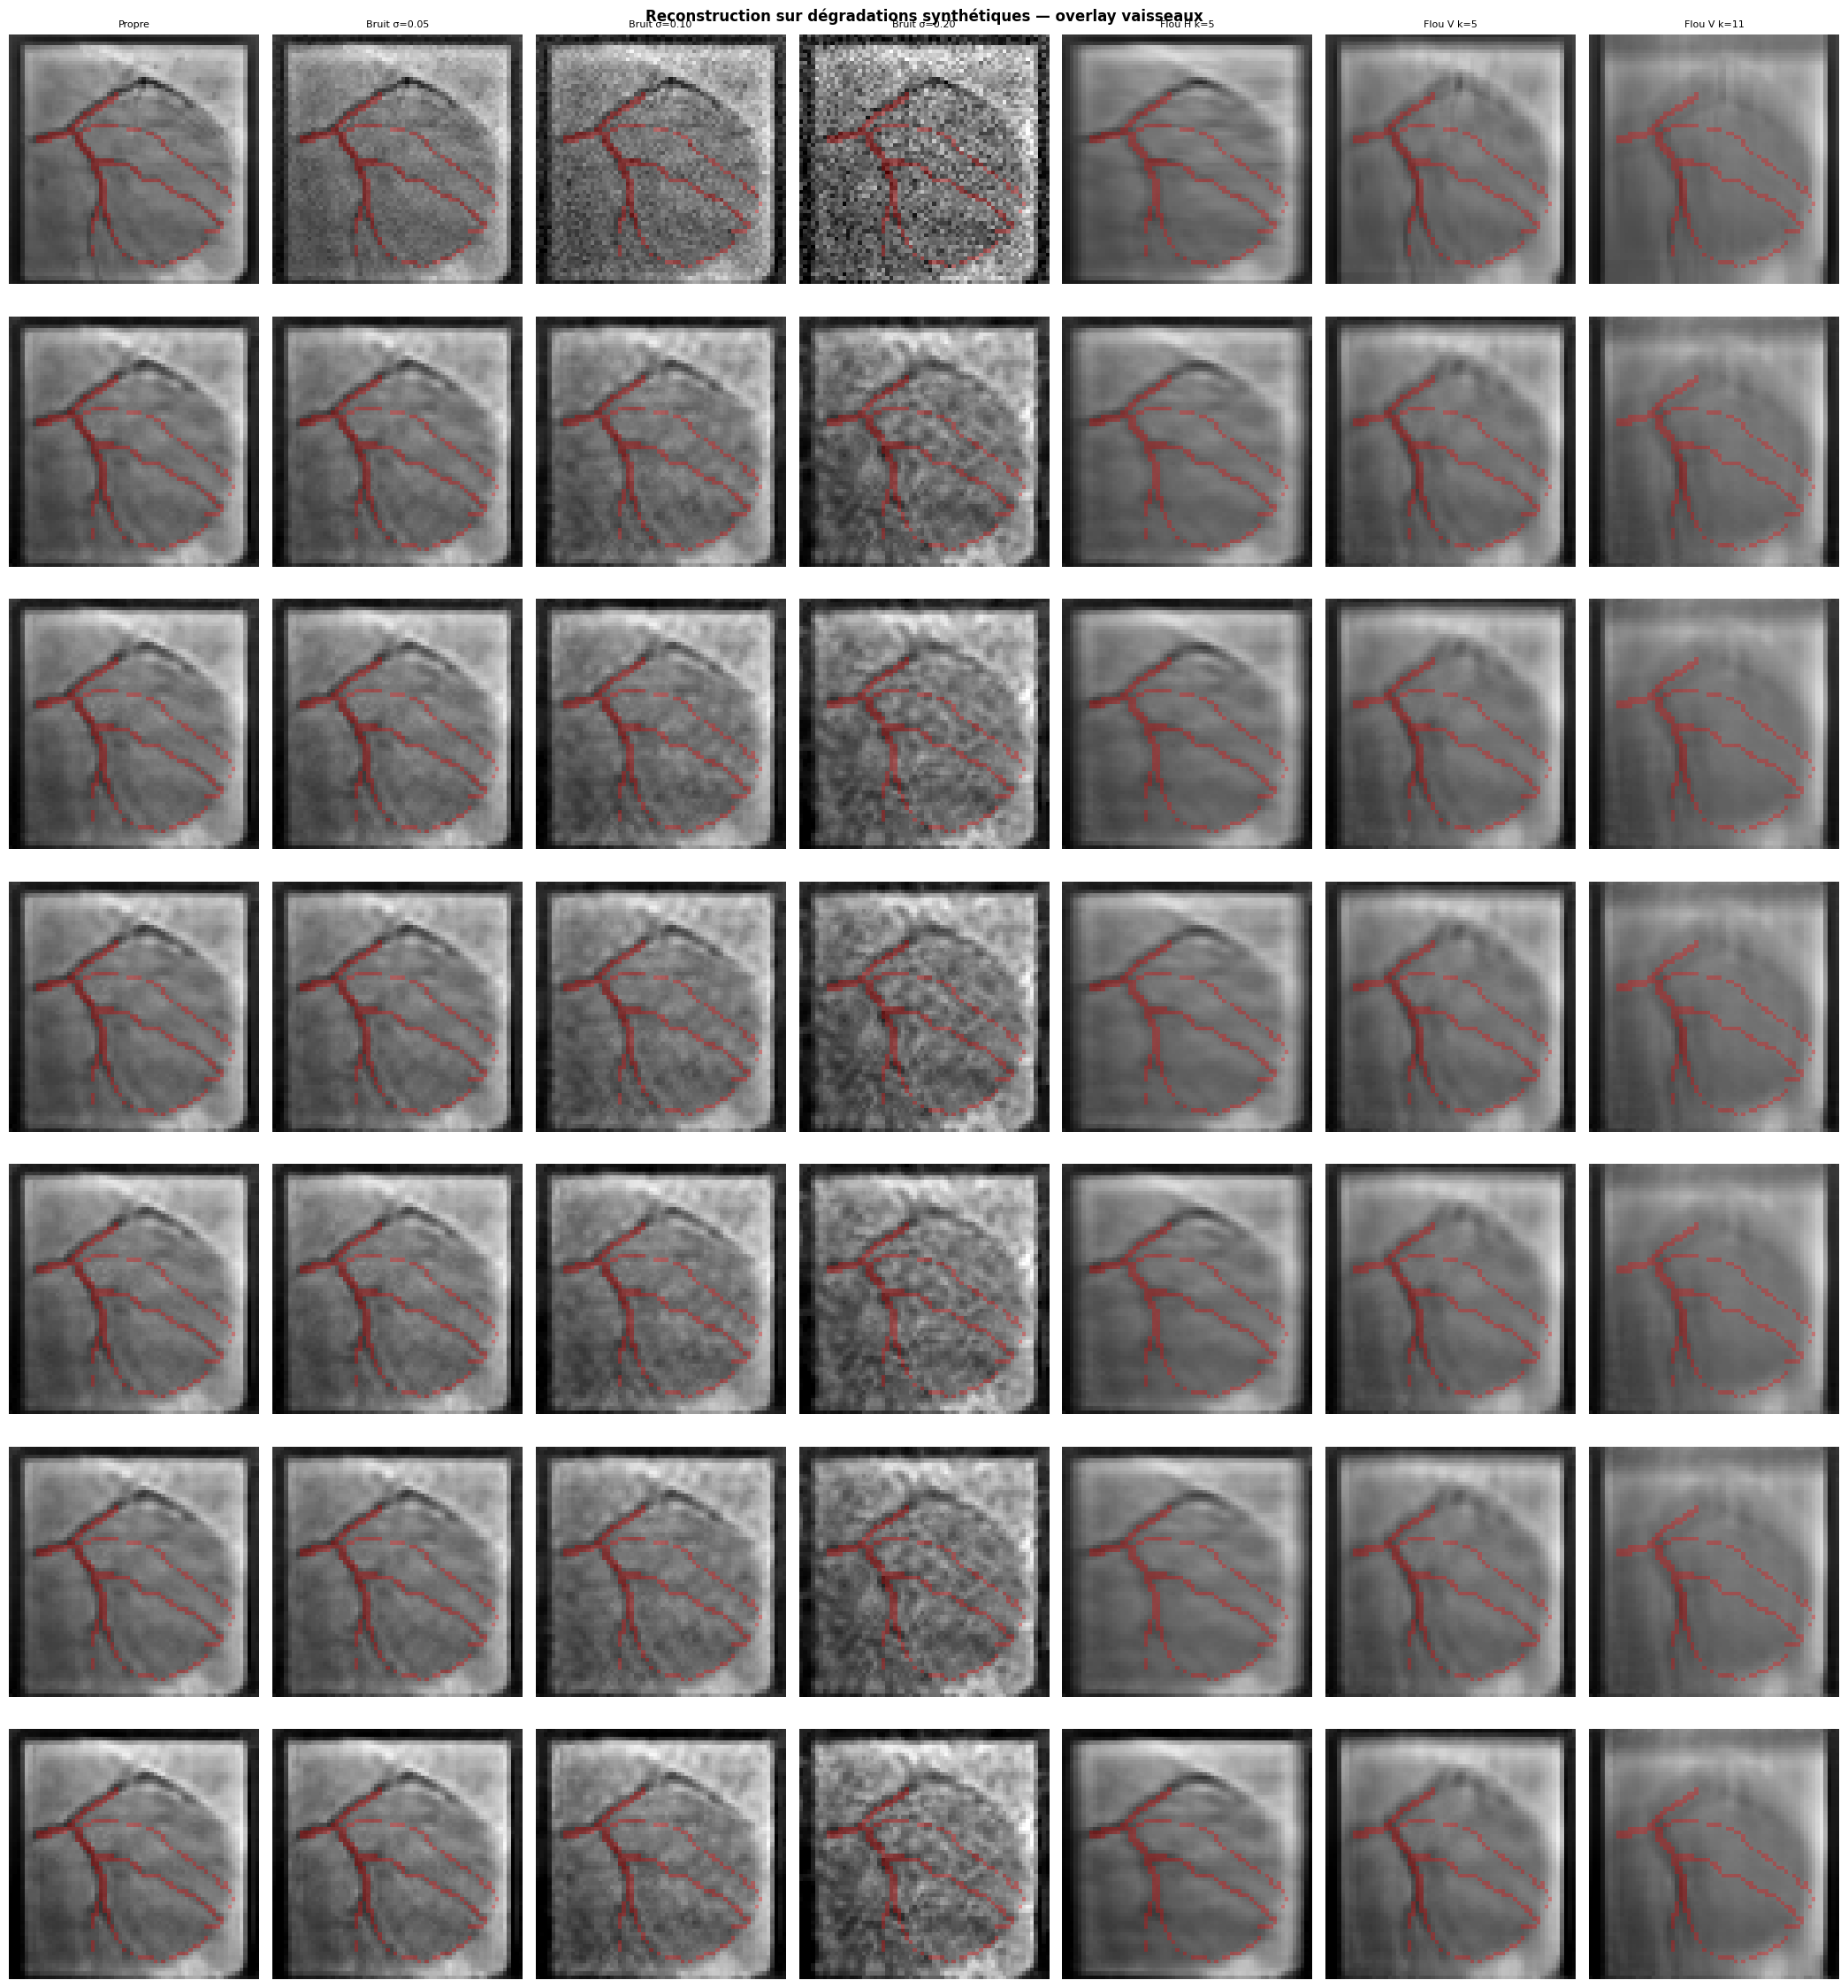

In [22]:
# Galerie sur dégradations synthétiques (benchmark contrôlé), même image de référence
# que la section 11 (_SYNTH_REF_KEY, première approche disponible)
if len(test_sets_by_approach[_SYNTH_REF_KEY]["good"]) > 0:
    x_gt_row = test_sets_by_approach[_SYNTH_REF_KEY]["good"].iloc[0]
    with torch.no_grad():
        x_gt = load_tensor(x_gt_row["path"]).to(DEVICE)
        mask64_gt = masked_mask_for(x_gt_row["path"], x_gt_row["split"], size=IMG_SIZE)

        n_rows = 1 + 2 * len(ACTIVE_APPROACHES)
        fig, axes = plt.subplots(n_rows, len(DEGRADATION_GRID), figsize=(3 * len(DEGRADATION_GRID), 3.3 * n_rows))
        row_labels = ["Dégradée (entrée)"] + [f"{r}_{k}" for k in ACTIVE_APPROACHES for r in ["baseline", "cvae"]]

        for col, d in enumerate(DEGRADATION_GRID):
            x_deg = d["fn"](x_gt)
            c_deg = torch.tensor([inline_quality_score(x_deg)], device=DEVICE)

            imgs = [to_uint8(x_deg)]
            metrics_strs = [""]
            for key in ACTIVE_APPROACHES:
                rec_base, _, _ = models[f"baseline_{key}"](x_deg, sample_posterior=False, decode=True)
                rec_cvae, _ = models[f"cvae_{key}"](x_deg, c_deg, sample_posterior=False)
                for rec_out in (rec_base, rec_cvae):
                    m = compute_all_metrics(x_gt, rec_out, x_gt_row["path"], x_gt_row["split"])
                    imgs.append(to_uint8(rec_out))
                    metrics_strs.append(f"PSNR={m['psnr']:.1f}\nMPSNR={m['masked_psnr']:.1f}")

            for row_idx, arr in enumerate(imgs):
                axes[row_idx, col].imshow(arr, cmap="gray", vmin=0, vmax=255)
                axes[row_idx, col].imshow(np.ma.masked_where(mask64_gt == 0, mask64_gt), cmap="autumn", alpha=0.3)
                axes[row_idx, col].axis("off")
                if metrics_strs[row_idx]:
                    axes[row_idx, col].set_xlabel(metrics_strs[row_idx], fontsize=7)
                if col == 0:
                    axes[row_idx, col].set_ylabel(row_labels[row_idx], fontsize=7)
            axes[0, col].set_title(d["name"], fontsize=8)

        fig.suptitle("Reconstruction sur dégradations synthétiques — overlay vaisseaux", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "07_gallery_synthetic_masked.png", dpi=130, bbox_inches="tight")
        plt.show()

## 13. Tableau récapitulatif final

In [23]:
print("=" * 90)
print(f"{'TABLEAU RÉCAPITULATIF — PSNR CLASSIQUE vs MASKED PSNR':^90}")
print("=" * 90)

all_results = []
for cmp in comparisons:
    df_cmp = cmp["df"]
    print(f"\n### {cmp['name']}")
    for metric, mlabel in [("psnr", "PSNR classique"), ("masked_psnr", "Masked PSNR")]:
        print(f"\n  {mlabel} ↑")
        print(f"  {'Classe':8s}  {'Base/réf':>14s}  {'cVAE':>14s}  {'Δ':>10s}  Amélioration")
        for label in label_order + ["ALL"]:
            sub = df_cmp if label == "ALL" else df_cmp[df_cmp["quality_label"] == label]
            if len(sub) == 0:
                continue
            mb, mc = sub[f"base_{metric}"].mean(), sub[f"cvae_{metric}"].mean()
            d = mc - mb
            marker = "amélioré" if d > 0 else "dégradé"
            pct = abs(d) / (abs(mb) + 1e-12) * 100
            print(f"  {label:8s}  {mb:14.4f}  {mc:14.4f}  {d:+10.4f}  {marker} ({pct:.1f}%)")
    df_export = df_cmp.copy()
    df_export.insert(0, "comparaison", cmp["name"])
    all_results.append(df_export)

df_results_full = pd.concat(all_results, ignore_index=True)
df_results_full.to_csv(TABLES_DIR / "07_full_results.csv", index=False)
print(f"\nRésultats complets exportés -> {TABLES_DIR / '07_full_results.csv'}")

                  TABLEAU RÉCAPITULATIF — PSNR CLASSIQUE vs MASKED PSNR                   

### baseline_A vs cvae_A

  PSNR classique ↑
  Classe          Base/réf            cVAE           Δ  Amélioration
  bad              33.8702         33.1330     -0.7372  dégradé (2.2%)
  medium           34.3018         33.4664     -0.8354  dégradé (2.4%)
  good             32.1105         31.3231     -0.7874  dégradé (2.5%)
  ALL              33.4275         32.6408     -0.7867  dégradé (2.4%)

  Masked PSNR ↑
  Classe          Base/réf            cVAE           Δ  Amélioration
  bad              31.4171         29.9611     -1.4560  dégradé (4.6%)
  medium           30.6152         29.7149     -0.9003  dégradé (2.9%)
  good             30.9648         29.8864     -1.0784  dégradé (3.5%)
  ALL              30.9991         29.8542     -1.1449  dégradé (3.7%)

### baseline_B vs cvae_B

  PSNR classique ↑
  Classe          Base/réf            cVAE           Δ  Amélioration
  bad              33.825

## 14. Conclusion

Le Masked PSNR restreint le calcul du MSE aux pixels appartenant à l'arbre
vasculaire annoté (≈2–6 % des pixels après le passage à 64×64), au lieu de la
totalité de l'image. Les sections ci-dessus permettent de répondre à la question
posée en introduction, pour les **3 approches** (A, B, C) et l'ablation $c$ constant :

- **Section 8b** indique, comparaison par comparaison et classe par classe, si le
  modèle gagnant change selon la métrique utilisée (`conclusion changée ?`).
- **Section 8c** quantifie la corrélation par image entre les deux métriques : une
  corrélation imparfaite (r < 1) montre que le Masked PSNR capture une information
  différente du PSNR classique, même s'il ne change pas systématiquement le
  classement moyen.
- **Sections 9–10** comparent les distributions et la significativité statistique
  des deux métriques côte à côte, pour chaque comparaison.
- **Section 11** montre si l'écart classique/masked se creuse avec la sévérité de
  la dégradation, pour les 3 approches.
- **Section 12** fournit la vérification visuelle demandée, approche par approche.

**Rappel méthodologique :** contrairement à une version précédente de ce notebook,
chaque cVAE est ici conditionné avec le score natif de son approche d'entraînement
(`score_weighted`/`score_pca`/`score_dl`), et les classes bad/medium/good sont
recalculées par approche — élimine toute contamination croisée entre approches.